# Modelagem Preditiva da Satisfação do Cliente

Este notebook apresenta a construção de uma solução de Machine Learning voltada à identificação de clientes com maior risco de insatisfação.

O objetivo é transformar informações de perfil, pedidos, entrega, atendimento e reclamações em previsões, explicações e indicadores capazes de apoiar ações de retenção e priorização no e-commerce.

### Etapas desenvolvidas

- definição da variável-alvo;
- criação de atributos derivados;
- divisão entre treino e teste;
- pré-processamento dos dados;
- verificação de baixa variabilidade com `VarianceThreshold`;
- treinamento e comparação de diferentes classificadores;
- otimização de hiperparâmetros com `RandomizedSearchCV`;
- comparação entre `RandomizedSearchCV` e Optuna;
- refinamento do XGBoost com Optuna em diferentes quantidades de trials;
- validação cruzada do modelo final;
- análise da importância das features;
- interpretabilidade do modelo com SHAP;
- transformação das probabilidades previstas em indicadores e ações de negócio.

Na etapa de Feature Selection, o `VarianceThreshold` será aplicado após o pré-processamento para verificar a existência de variáveis constantes ou com baixa variabilidade.

Como a base apresenta desbalanceamento entre as classes, a avaliação será orientada principalmente por métricas como **F1 Macro, Recall, F1-score, ROC-AUC e matriz de confusão**, buscando bom desempenho sem favorecer excessivamente uma única classe.

Após a seleção do modelo final, a análise com **SHAP** será utilizada para compreender a influência das variáveis tanto de forma global quanto em previsões individuais, aumentando a transparência e a interpretabilidade da solução.

> O resultado esperado é uma solução capaz de identificar clientes com maior risco de insatisfação, explicar os principais fatores associados às previsões e transformar esses resultados em informações úteis para retenção, priorização de atendimento e tomada de decisão.

#1. Preparação do ambiente

Nesta etapa serão importadas as bibliotecas utilizadas para manipulação dos dados, pré-processamento, treinamento, avaliação e salvamento dos modelos.

In [1]:
# ================================
# Manipulação de dados
# ================================
import pandas as pd
import numpy as np

# ================================
# Visualização de dados
# ================================
import matplotlib.pyplot as plt
import seaborn as sns

# ================================
# Salvamento de modelos
# ================================
import joblib

# ================================
# Divisão dos dados
# ================================
from sklearn.model_selection import train_test_split

# ================================
# Pré-processamento
# ================================
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# ================================
# Modelos de Machine Learning
# ================================
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
import xgboost as xgb

# ================================
# Avaliação de modelos
# ================================
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

# ================================
# Validação e otimização
# ================================
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import cross_validate, StratifiedKFold, cross_val_score

import time




In [2]:
!pip install optuna

In [3]:
import optuna
import optuna.visualization as viz

c:\Users\treve\OneDrive\Documentos\Renan - Projetos\customer-churn-prediction\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# 2. Leitura da base tratada

Nesta etapa será carregada a base preparada no notebook de entendimento e tratamento dos dados.

Como as etapas de limpeza, tradução das colunas, verificação de valores ausentes, análise de duplicidades e seleção inicial de variáveis já foram realizadas anteriormente, este notebook utilizará diretamente a versão tratada da base.

Após o carregamento, serão exibidas as primeiras observações para confirmar que o arquivo foi lido corretamente.

In [4]:
dados = pd.read_csv(
    "../data/processed/clientes_tratados.csv"
)

dados.head()

,idade_cliente,regiao_cliente,tempo_cliente_meses,valor_pedido,quantidade_itens,valor_desconto,parcelas_pagamento,tempo_entrega_dias,atraso_entrega_dias,valor_frete,tentativas_entrega,contatos_atendimento,tempo_resolucao_dias,nps,numero_reclamacoes
0,63,Nordeste,14,139.73,4,39.35,4,2,2,55.53,3,0,4,6.9,3
1,20,Sul,1,458.95,2,9.51,10,6,4,28.23,3,0,10,2.4,3
2,46,Nordeste,111,507.06,5,42.82,6,6,1,40.99,1,4,5,4.8,7
3,52,Centro-Oeste,117,302.19,2,19.58,9,5,2,35.24,3,1,11,5.9,4
4,56,Norte,50,253.06,1,29.37,11,13,1,39.32,1,1,0,6.1,3


# 3. Validação rápida dos dados

Antes de iniciar a modelagem, será realizada uma verificação rápida da base para confirmar se sua estrutura permanece consistente após o processo de tratamento.

Nesta etapa serão conferidos:

- a quantidade de registros e variáveis;
- os tipos das colunas;
- a presença de valores ausentes;
- a existência de registros duplicados.

Essa validação funciona como um controle de qualidade antes da criação das features e do treinamento dos modelos.

In [5]:
print(f'Total de linhas: {dados.shape[0]}')
print(f'Total de colunas: {dados.shape[1]}')

Total de linhas: 2500
Total de colunas: 15


In [6]:
dados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   idade_cliente         2500 non-null   int64  
 1   regiao_cliente        2500 non-null   object 
 2   tempo_cliente_meses   2500 non-null   int64  
 3   valor_pedido          2500 non-null   float64
 4   quantidade_itens      2500 non-null   int64  
 5   valor_desconto        2500 non-null   float64
 6   parcelas_pagamento    2500 non-null   int64  
 7   tempo_entrega_dias    2500 non-null   int64  
 8   atraso_entrega_dias   2500 non-null   int64  
 9   valor_frete           2500 non-null   float64
 10  tentativas_entrega    2500 non-null   int64  
 11  contatos_atendimento  2500 non-null   int64  
 12  tempo_resolucao_dias  2500 non-null   int64  
 13  nps                   2500 non-null   float64
 14  numero_reclamacoes    2500 non-null   int64  
dtypes: float64(4), int64(

In [7]:
print(f'Valores Ausentes: {dados.isna().sum().sum()}')
print(f'Valores Duplicados: {dados.duplicated().sum()}')

Valores Ausentes: 0
Valores Duplicados: 0


#4. Definição da variável-alvo

Nesta etapa, a nota de NPS será transformada em uma variável binária para representar o risco de insatisfação do cliente.

A classificação será definida da seguinte forma:

- `1`: cliente detrator, com nota de NPS entre 0 e 6;
- `0`: cliente não detrator, com nota de NPS acima de 6.

Essa transformação permite tratar o problema como uma tarefa de classificação binária, na qual o objetivo será identificar clientes com maior probabilidade de insatisfação.

In [8]:
# transformando em 0 e 1 - valores 1 representam os detratores
dados['target'] = pd.cut(dados['nps'],
                         bins=[-1, 6., np.inf],
                         labels=[1, 0])

In [9]:
dados['target'].value_counts()

target
1    1851
0     649
Name: count, dtype: int64

In [10]:
# Fazendo o drop do nps agora, já que iremos utilizar a target
dados = dados.drop('nps', axis=1)

# 5. Engenharia de atributos

Com base nos padrões identificados durante a análise exploratória, serão criadas novas variáveis para representar situações críticas na experiência do cliente.

As variáveis derivadas são:

- `atraso_critico`: indica atrasos iguais ou superiores a 2 dias;
- `problema_complexo`: identifica situações com pelo menos 2 contatos com o atendimento e tempo de resolução igual ou superior a 3 dias;
- `reclamacao_recorrente`: indica clientes com 3 ou mais reclamações.

Essas novas features resumem comportamentos relevantes e poderão ajudar os modelos a identificar padrões associados à insatisfação.

In [11]:
dados['atraso_critico'] = (dados['atraso_entrega_dias'] >= 2).astype(int)

dados['problema_complexo'] = (
    (dados['contatos_atendimento'] >= 2) &
    (dados['tempo_resolucao_dias'] >= 3)
).astype(int)

dados['reclamacao_recorrente'] = (dados['numero_reclamacoes'] >= 3).astype(int)

In [12]:
dados.head()

,idade_cliente,regiao_cliente,tempo_cliente_meses,valor_pedido,quantidade_itens,valor_desconto,parcelas_pagamento,tempo_entrega_dias,atraso_entrega_dias,valor_frete,tentativas_entrega,contatos_atendimento,tempo_resolucao_dias,numero_reclamacoes,target,atraso_critico,problema_complexo,reclamacao_recorrente
0,63,Nordeste,14,139.73,4,39.35,4,2,2,55.53,3,0,4,3,0,1,0,1
1,20,Sul,1,458.95,2,9.51,10,6,4,28.23,3,0,10,3,1,1,0,1
2,46,Nordeste,111,507.06,5,42.82,6,6,1,40.99,1,4,5,7,1,0,1,1
3,52,Centro-Oeste,117,302.19,2,19.58,9,5,2,35.24,3,1,11,4,1,1,0,1
4,56,Norte,50,253.06,1,29.37,11,13,1,39.32,1,1,0,3,0,0,0,1


# 6. Divisão dos dados em treino e teste

Nesta etapa, o conjunto de dados será separado entre variáveis explicativas e variável-alvo.

- `X`: contém as variáveis utilizadas pelos modelos;
- `y`: contém a variável `target`, que indica se o cliente é detrator.

Em seguida, os dados serão divididos em conjuntos de treino e teste.

O conjunto de treino será utilizado para ajustar os modelos, enquanto o conjunto de teste será reservado para a avaliação final.

A divisão será estratificada pela variável-alvo, preservando a proporção de clientes detratores e não detratores nos dois conjuntos.

In [13]:
X = dados.drop('target', axis=1)
y = dados['target']

In [14]:
X_treino, X_teste, y_treino, y_teste = train_test_split(X, y, stratify=y,test_size=0.2, random_state=42)

In [15]:
print(f'Treino: {X_treino.shape[0]}')
print(f'Teste: {X_teste.shape[0]}')

Treino: 2000
Teste: 500


In [16]:
colunas_entrada = X_treino.columns

In [17]:
df = X_teste.copy()

# 7. Pré-processamento dos dados

Nesta etapa, as variáveis serão preparadas para o treinamento dos modelos.

As colunas numéricas serão padronizadas com `StandardScaler`, enquanto a variável categórica `regiao_cliente` será transformada por meio de One-Hot Encoding.

A padronização é importante para modelos sensíveis à escala, como Regressão Logística, KNN e SVM. Já o One-Hot Encoding converte categorias textuais em colunas numéricas, permitindo seu uso pelos algoritmos.

O pré-processador será ajustado somente com os dados de treino e depois aplicado ao conjunto de teste, evitando vazamento de informações.

In [18]:
col_numericas = ['idade_cliente', 'tempo_cliente_meses', 'valor_pedido', 'quantidade_itens', 'valor_desconto', 'parcelas_pagamento', 'tempo_entrega_dias', 'atraso_entrega_dias',
             'valor_frete', 'tentativas_entrega', 'contatos_atendimento', 'tempo_resolucao_dias', 'numero_reclamacoes', 'atraso_critico', 'problema_complexo', 'reclamacao_recorrente']
col_categoricas = ['regiao_cliente']

In [19]:
full_pipeline = ColumnTransformer([
    ("num", StandardScaler(), col_numericas),
    ("cat", OneHotEncoder(drop="first", handle_unknown="ignore",sparse_output=False), col_categoricas)
])

In [20]:
x_treino_tratado = full_pipeline.fit_transform(X_treino)
x_teste_tratado = full_pipeline.transform(X_teste)

In [21]:
num_cols = list(col_numericas)
cat_cols = full_pipeline.named_transformers_['cat'].get_feature_names_out(col_categoricas)

X_treino = pd.DataFrame(x_treino_tratado, columns=num_cols + list(cat_cols))
X_teste = pd.DataFrame(x_teste_tratado, columns=num_cols + list(cat_cols))

In [22]:
X_treino.head()

,idade_cliente,tempo_cliente_meses,valor_pedido,quantidade_itens,valor_desconto,parcelas_pagamento,tempo_entrega_dias,atraso_entrega_dias,valor_frete,tentativas_entrega,contatos_atendimento,tempo_resolucao_dias,numero_reclamacoes,atraso_critico,problema_complexo,reclamacao_recorrente,regiao_cliente_Nordeste,regiao_cliente_Norte,regiao_cliente_Sudeste,regiao_cliente_Sul
0,-1.228616,-1.060464,-0.323005,-1.465588,0.012322,-1.582239,-1.081564,1.231576,-2.031869,-1.231045,-0.422476,-0.727218,-0.652053,0.745124,-0.730577,0.449359,0.0,0.0,0.0,1.0
1,0.911306,-0.275312,2.674934,0.315199,-0.949631,-0.625336,1.580419,0.550771,0.343444,-1.231045,1.215029,-0.436156,1.040859,0.745124,1.368782,0.449359,0.0,0.0,0.0,1.0
2,1.045051,0.335362,0.985016,0.315199,-0.814828,0.012599,-0.549167,-1.491644,-1.062387,-1.231045,2.033782,0.437030,2.169466,-1.342058,1.368782,0.449359,1.0,0.0,0.0,0.0
3,-0.225528,0.975115,-0.569380,-1.465588,0.345084,1.607438,-0.549167,-0.130034,-1.414255,1.222458,-0.422476,-0.727218,-1.216357,0.745124,-0.730577,-2.225395,0.0,0.0,0.0,1.0
4,-0.961126,-0.478870,-0.190397,0.908795,-0.289201,-0.306368,1.580419,1.231576,0.326220,-0.004294,-0.422476,-1.309342,-0.087749,0.745124,-0.730577,0.449359,0.0,0.0,1.0,0.0


# 8. Aplicação do VarianceThreshold

Após o pré-processamento dos dados, foi aplicado o método `VarianceThreshold` com o objetivo de verificar a existência de features com baixa variabilidade.

Como as variáveis categóricas já haviam sido transformadas em valores numéricos pelo `OneHotEncoder`, tornou-se possível aplicar o método diretamente sobre o conjunto tratado.

Foi utilizado o parâmetro `threshold=0.1`, responsável por remover features cuja variância esteja abaixo desse limite.

O método foi ajustado apenas com os dados de treino e, posteriormente, aplicado ao conjunto de teste, mantendo o mesmo padrão de transformação e evitando vazamento de informação.


In [23]:
from sklearn.feature_selection import VarianceThreshold

selector_variance = VarianceThreshold(threshold=0.1)

X_treino_variance = selector_variance.fit_transform(X_treino)
X_teste_variance = selector_variance.transform(X_teste)

features_variance = X_treino.columns[selector_variance.get_support()]

print(f'Features Originais : {X_treino.shape[1]}')
print(f'Features Selecionadas: {len(features_variance)}')

print('\nFeatures Mantidas:')
print(features_variance.tolist())

Features Originais : 20
Features Selecionadas: 20

Features Mantidas:
['idade_cliente', 'tempo_cliente_meses', 'valor_pedido', 'quantidade_itens', 'valor_desconto', 'parcelas_pagamento', 'tempo_entrega_dias', 'atraso_entrega_dias', 'valor_frete', 'tentativas_entrega', 'contatos_atendimento', 'tempo_resolucao_dias', 'numero_reclamacoes', 'atraso_critico', 'problema_complexo', 'reclamacao_recorrente', 'regiao_cliente_Nordeste', 'regiao_cliente_Norte', 'regiao_cliente_Sudeste', 'regiao_cliente_Sul']


### Interpretação

O conjunto possuía inicialmente 20 features e, após a aplicação do `VarianceThreshold`, todas as 20 foram mantidas.

Esse resultado indica que nenhuma das variáveis apresentou variância inferior ao limite definido de `0.1`.

Portanto, não foram identificadas features com baixa variabilidade suficiente para justificar sua remoção nessa etapa.

Dessa forma, todas as variáveis foram preservadas para as próximas etapas de modelagem e seleção de atributos.


# 9. Treinamento e comparação inicial dos modelos

Nesta etapa, diferentes algoritmos de classificação serão treinados utilizando os mesmos conjuntos de treino e teste.

Foram selecionados modelos com características distintas:

- Regressão Logística;
- Árvore de Decisão;
- Random Forest;
- K-Nearest Neighbors;
- Support Vector Machine;
- Naive Bayes;
- XGBoost.

O objetivo desta comparação inicial é identificar quais algoritmos apresentam melhor desempenho na classificação de clientes detratores e não detratores.

Como a base apresenta desbalanceamento entre as classes, a análise não será baseada somente na acurácia. Também serão avaliadas precision, recall e F1-score para cada classe.

In [24]:
modelos_classificacao = {
    "Regressão Logística": LogisticRegression(random_state=42, max_iter=2000, class_weight="balanced"),

    "Árvore de Decisão": DecisionTreeClassifier(random_state=42, class_weight="balanced"),

    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42, class_weight="balanced",
        n_jobs=-1),

    "KNN": KNeighborsClassifier(n_neighbors=5),

    "SVM": SVC(kernel="rbf", class_weight="balanced", probability=True, random_state=42),

    "Naive Bayes": GaussianNB(),

    "XGBoost": XGBClassifier(random_state=42)
}

In [25]:
resultados = []

for nome, modelo in modelos_classificacao.items():
    modelo.fit(X_treino, y_treino)
    pred = modelo.predict(X_teste)

    resultados.append({
        "Modelo": nome,
        "Accuracy": accuracy_score(y_teste, pred),
        "Precision_0": precision_score(y_teste, pred, pos_label=0),
        "Precision_1": precision_score(y_teste, pred, pos_label=1),
        "Recall_0": recall_score(y_teste, pred, pos_label=0),
        "Recall_1": recall_score(y_teste, pred, pos_label=1),
        "F1-score": f1_score(y_teste, pred)
    })

resultados_df = pd.DataFrame(resultados).sort_values(by="F1-score", ascending=False)
print("====== Resultados dos Modelos Ordenados por F1-Score ======\n")
resultados_df.round(3)

====== Resultados dos Modelos Ordenados por F1-Score ======



,Modelo,Accuracy,Precision_0,Precision_1,Recall_0,Recall_1,F1-score
2,Random Forest,0.838,0.743,0.862,0.577,0.930,0.895
6,XGBoost,0.818,0.689,0.851,0.546,0.914,0.881
3,KNN,0.800,0.647,0.839,0.508,0.903,0.870
5,Naive Bayes,0.808,0.620,0.883,0.677,0.854,0.868
1,Árvore de Decisão,0.778,0.586,0.833,0.500,0.876,0.854
0,Regressão Logística,0.798,0.580,0.922,0.808,0.795,0.853
4,SVM,0.794,0.574,0.921,0.808,0.789,0.850


In [26]:
# Selecionando o top3 modelos
for nome in['Random Forest', 'XGBoost', 'KNN']:
  modelo = modelos_classificacao[nome]
  modelo.fit(X_treino, y_treino)
  pred = modelo.predict(X_teste)

  print(f'\n\nModelo: {nome}')
  print(classification_report(y_teste, pred))



Modelo: Random Forest
              precision    recall  f1-score   support

           0       0.74      0.58      0.65       130
           1       0.86      0.93      0.89       370

    accuracy                           0.84       500
   macro avg       0.80      0.75      0.77       500
weighted avg       0.83      0.84      0.83       500



Modelo: XGBoost
              precision    recall  f1-score   support

           0       0.69      0.55      0.61       130
           1       0.85      0.91      0.88       370

    accuracy                           0.82       500
   macro avg       0.77      0.73      0.75       500
weighted avg       0.81      0.82      0.81       500



Modelo: KNN
              precision    recall  f1-score   support

           0       0.65      0.51      0.57       130
           1       0.84      0.90      0.87       370

    accuracy                           0.80       500
   macro avg       0.74      0.71      0.72       500
weighted avg      

### Comparação inicial dos modelos

O **Random Forest** apresentou o melhor desempenho inicial, com acurácia de aproximadamente **84%**, seguido pelo **XGBoost**, com cerca de **82%**. Ambos também obtiveram bons valores de recall para a classe positiva.

O **KNN** apresentou desempenho inferior, principalmente na identificação da classe 0, indicando maior dificuldade em reconhecer corretamente esse grupo.

De forma geral, **Random Forest e XGBoost** se destacaram como os modelos mais promissores para as próximas etapas.

Como a base apresenta desbalanceamento entre as classes, a seleção dos modelos não será baseada apenas na acurácia. Também serão consideradas métricas como **F1 Macro**, **balanced accuracy** e **recall por classe**.


# 10. Otimização de hiperparâmetros

Após a comparação inicial dos algoritmos, foram selecionados XGBoost, Random Forest e KNN para a etapa de otimização.

O objetivo é buscar combinações de hiperparâmetros capazes de melhorar o desempenho e a capacidade de generalização dos modelos.

A otimização será realizada com `RandomizedSearchCV`, utilizando validação cruzada com cinco divisões e F1 Macro como métrica principal, já que essa métrica considera o desempenho das duas classes de forma equilibrada.

In [27]:
# Modelos a serem utilizados
xgb_model = XGBClassifier(random_state=42)

rf_model = RandomForestClassifier(random_state=42, n_jobs=-1, class_weight='balanced')

knn_model = KNeighborsClassifier()

### Espaços de busca

Para cada algoritmo, foram definidos conjuntos de hiperparâmetros relacionados à complexidade, regularização e comportamento do modelo.

O `RandomizedSearchCV` testará diferentes combinações dentro desses espaços, reduzindo o custo computacional em comparação com uma busca exaustiva.

In [28]:
# Params XGBoost
param_dist_xgb = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [2, 3, 4],
    "min_child_weight": [1, 3, 5, 10],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0],
    "gamma": [0, 0.1, 0.5, 1],
    # Regularização L1
    "reg_alpha": [0, 0.01, 0.1, 1],
    # Regularização L2
    "reg_lambda": [0.1, 1, 5, 10]
}
# Params Random Forest
param_dist_rf = {
    "n_estimators": [200, 300, 500],
    "max_depth": [None, 5, 10, 15, 20],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4, 8],
    "max_features": ["sqrt", "log2", 0.5],
    "bootstrap": [True, False]
}
# Parâmetros do KNN
param_dist_knn = {
    "n_neighbors": [3, 5, 7, 9, 11, 15, 21],
    "weights": ["uniform", "distance"],
    "metric": ["euclidean", "manhattan"]
}

In [29]:
random_xgb = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=param_dist_xgb,
    n_iter=20,
    scoring='f1_macro',
    cv=5,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

random_rf = RandomizedSearchCV(
    estimator=rf_model,
    param_distributions=param_dist_rf,
    n_iter=20,
    scoring='f1_macro',
    cv=5,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

random_knn = RandomizedSearchCV(
    estimator=knn_model,
    param_distributions=param_dist_knn,
    n_iter=20,
    scoring='f1_macro',
    cv=5,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

### Execução da otimização

As buscas serão ajustadas utilizando apenas o conjunto de treino.

Ao final, será selecionada a combinação de hiperparâmetros que apresentar o melhor desempenho médio durante a validação cruzada.

In [30]:
# Treino XGB + time
inicio = time.perf_counter()
random_xgb.fit(X_treino, y_treino)
tempo_xgb = time.perf_counter() - inicio

# Treino RF + time
inicio = time.perf_counter()
random_rf.fit(X_treino, y_treino)
tempo_rf = time.perf_counter() - inicio

# Treino KNN + time
inicio = time.perf_counter()
random_knn.fit(X_treino, y_treino)
tempo_knn = time.perf_counter() - inicio

print("XGBoost - melhores parâmetros:")
print(random_xgb.best_params_)
print()

print("Random Forest - melhores parâmetros:")
print(random_rf.best_params_)
print()

print("KNN - melhores parâmetros:")
print(random_knn.best_params_)
print()

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Fitting 5 folds for each of 20 candidates, totalling 100 fits
Fitting 5 folds for each of 20 candidates, totalling 100 fits
XGBoost - melhores parâmetros:
{'subsample': 0.9, 'reg_lambda': 5, 'reg_alpha': 0, 'n_estimators': 300, 'min_child_weight': 3, 'max_depth': 2, 'learning_rate': 0.05, 'gamma': 0.1, 'colsample_bytree': 0.8}

Random Forest - melhores parâmetros:
{'n_estimators': 300, 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': 20, 'bootstrap': True}

KNN - melhores parâmetros:
{'weights': 'distance', 'n_neighbors': 7, 'metric': 'euclidean'}



### Avaliação dos modelos otimizados

Após a otimização, os melhores estimadores serão avaliados no conjunto de teste.

Serão analisadas métricas como acurácia, precision, recall e F1-score para cada classe.

Nesta etapa, os resultados serão apenas registrados. A escolha do modelo final será realizada posteriormente, após a comparação visual apresentada na próxima seção.

In [31]:
modelos_tunados = {
    "XGBoost Tunado": random_xgb.best_estimator_,
    "Random Forest Tunado": random_rf.best_estimator_,
    "KNN Tunado": random_knn.best_estimator_
}

resultados_tuning = []

for nome, modelo in modelos_tunados.items():
    pred = modelo.predict(X_teste)

    resultados_tuning.append({
      'Modelo': nome,
      'Acurácia': accuracy_score(y_teste, pred),
      'Recall_0': recall_score(y_teste, pred, pos_label=0),
      'Recall_1': recall_score(y_teste, pred, pos_label=1),
      'Precision_0': precision_score(y_teste, pred, pos_label=0),
      'Precision_1': precision_score(y_teste, pred, pos_label=1),
      'F1-Score': f1_score(y_teste, pred)
    })

resultados_tuning_df = pd.DataFrame(resultados_tuning).sort_values(
    by="F1-Score", ascending=False
)


print(f"Tempo XGBoost: {tempo_xgb:.2f} segundos")
print(f"Tempo Random Forest: {tempo_rf:.2f} segundos")
print(f"Tempo KNN: {tempo_knn:.2f} segundos")
print()
resultados_tuning_df.round(4)

Tempo XGBoost: 5.54 segundos
Tempo Random Forest: 16.09 segundos
Tempo KNN: 0.32 segundos



,Modelo,Acurácia,Recall_0,Recall_1,Precision_0,Precision_1,F1-Score
1,Random Forest Tunado,0.834,0.6769,0.8892,0.6822,0.8868,0.8880
0,XGBoost Tunado,0.824,0.5692,0.9135,0.6981,0.8579,0.8848
2,KNN Tunado,0.800,0.5154,0.9000,0.6442,0.8409,0.8695


In [32]:
for nome in ["XGBoost Tunado", "Random Forest Tunado", "KNN Tunado"]:
    modelo = modelos_tunados[nome]
    modelo.fit(X_treino, y_treino)
    pred = modelo.predict(X_teste)

    print(f"\n=== {nome} ===")
    print(classification_report(y_teste, pred))


=== XGBoost Tunado ===
              precision    recall  f1-score   support

           0       0.70      0.57      0.63       130
           1       0.86      0.91      0.88       370

    accuracy                           0.82       500
   macro avg       0.78      0.74      0.76       500
weighted avg       0.82      0.82      0.82       500


=== Random Forest Tunado ===
              precision    recall  f1-score   support

           0       0.68      0.68      0.68       130
           1       0.89      0.89      0.89       370

    accuracy                           0.83       500
   macro avg       0.78      0.78      0.78       500
weighted avg       0.83      0.83      0.83       500


=== KNN Tunado ===
              precision    recall  f1-score   support

           0       0.64      0.52      0.57       130
           1       0.84      0.90      0.87       370

    accuracy                           0.80       500
   macro avg       0.74      0.71      0.72       500


### Síntese da otimização

A otimização gerou versões ajustadas dos modelos XGBoost, Random Forest e KNN.

Os resultados mostram diferenças no equilíbrio entre a identificação das classes `0` e `1`, mas ainda não será realizada a escolha definitiva do modelo.

Na próxima etapa, as métricas serão comparadas visualmente para apoiar uma decisão mais clara e fundamentada.

# 11. Análise gráfica dos modelos otimizados

Nesta etapa, os modelos otimizados serão comparados por meio das matrizes de confusão e das curvas ROC.

As matrizes de confusão permitem observar como cada algoritmo classificou as classes `0` e `1`, enquanto a curva ROC avalia a capacidade de separação entre clientes detratores e não detratores em diferentes limiares de decisão.

A análise conjunta dessas visualizações será utilizada para apoiar a escolha do modelo final.

## Matrizes de confusão

As matrizes de confusão mostram os acertos e erros de classificação de cada modelo.

Neste projeto:

- `0` representa clientes não detratores;
- `1` representa clientes detratores.

Além do total de acertos, será observado o equilíbrio entre a identificação das duas classes.

In [33]:
modelo_xgb_final = random_xgb.best_estimator_
modelo_rf_final = random_rf.best_estimator_
modelo_knn_final = random_knn.best_estimator_

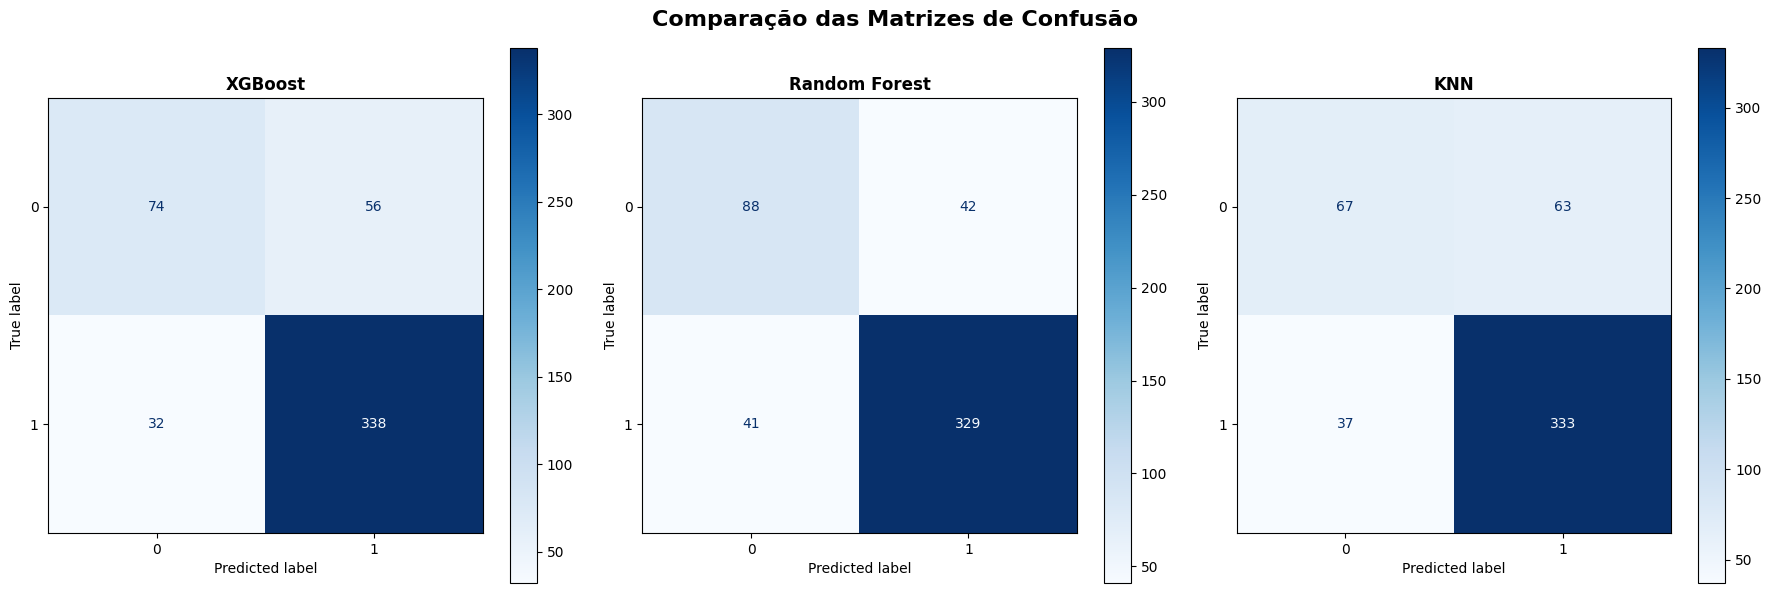

In [34]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# XGBoost
ConfusionMatrixDisplay.from_estimator(modelo_xgb_final, X_teste, y_teste, cmap="Blues", ax=axes[0], colorbar=True)
axes[0].set_title("XGBoost", fontweight="bold")


# Random Forest
ConfusionMatrixDisplay.from_estimator(modelo_rf_final, X_teste, y_teste, cmap="Blues", ax=axes[1], colorbar=True)
axes[1].set_title("Random Forest", fontweight="bold")


# KNN
ConfusionMatrixDisplay.from_estimator(modelo_knn_final, X_teste, y_teste, cmap="Blues", ax=axes[2], colorbar=True)
axes[2].set_title("KNN", fontweight="bold")

# Título geral
plt.suptitle("Comparação das Matrizes de Confusão", fontsize=16, fontweight="bold")

plt.tight_layout()
plt.show()

### Interpretação das matrizes de confusão

O **XGBoost** classificou corretamente **73 clientes da classe 0** e **342 da classe 1**, apresentando boa capacidade de identificar a classe positiva, embora ainda tenha classificado **57 clientes da classe 0 como classe 1**.

O **Random Forest** apresentou o melhor equilíbrio entre as duas classes, identificando corretamente **88 clientes da classe 0** e **329 da classe 1**.

O **KNN** classificou corretamente **333 clientes da classe 1**, porém apresentou maior dificuldade na classe 0, com **63 classificações incorretas**.

De forma geral, o **XGBoost** apresentou maior sensibilidade para a classe positiva, enquanto o **Random Forest** demonstrou comportamento mais equilibrado entre as duas classes.


## Curvas ROC

A curva ROC representa a relação entre a taxa de verdadeiros positivos e a taxa de falsos positivos em diferentes limites de classificação.

A área sob a curva, conhecida como AUC, varia entre 0 e 1. Quanto maior o valor, maior a capacidade do modelo de diferenciar as duas classes.

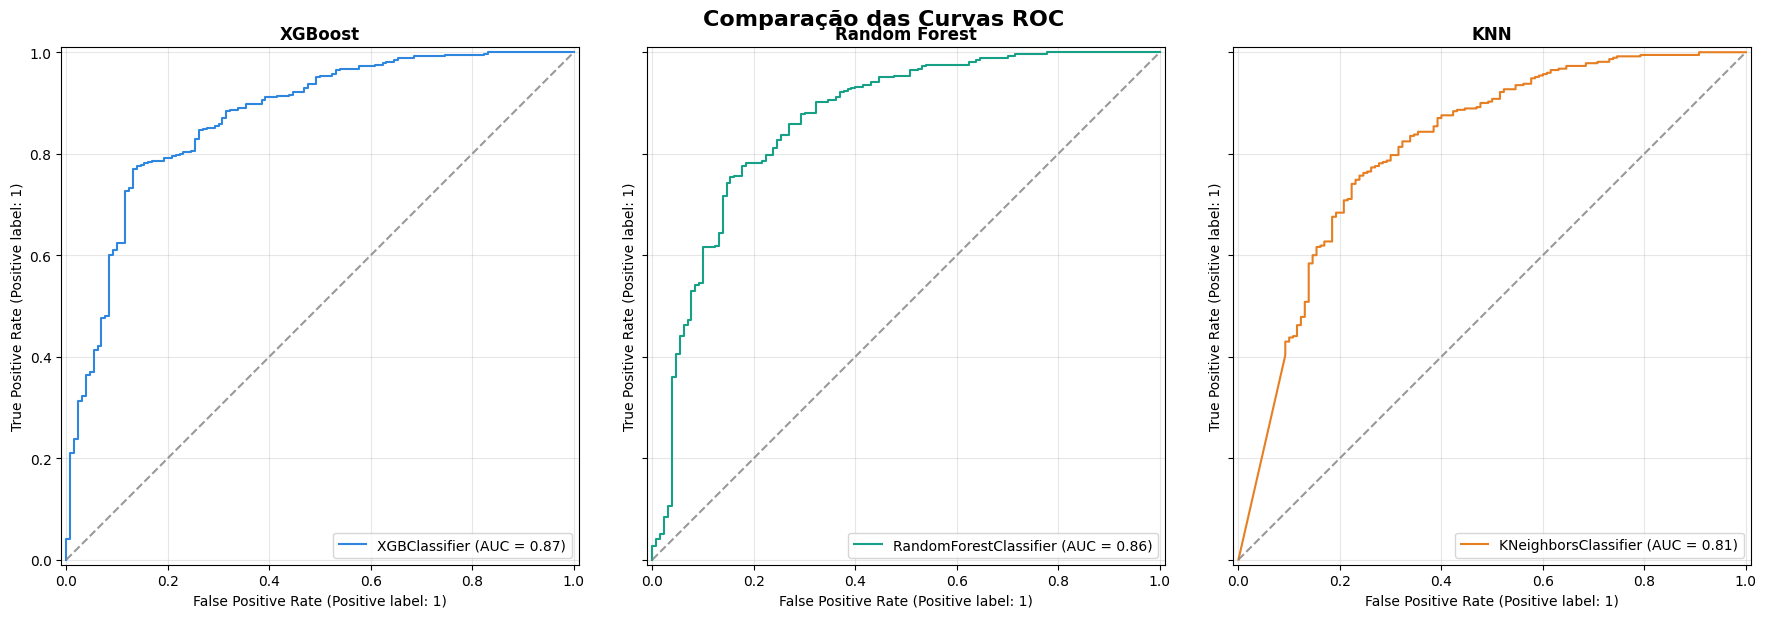

In [35]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharex=True, sharey=True)

# XGBoost
RocCurveDisplay.from_estimator(modelo_xgb_final, X_teste, y_teste, ax=axes[0], color="#2E86DE")
axes[0].plot([0, 1], [0, 1], linestyle="--", color="gray", alpha=0.8)
axes[0].set_title("XGBoost", fontweight="bold")
axes[0].grid(alpha=0.3)

# Random Forest
RocCurveDisplay.from_estimator(modelo_rf_final, X_teste, y_teste, ax=axes[1], color="#16A085")
axes[1].plot([0, 1], [0, 1], linestyle="--", color="gray", alpha=0.8)
axes[1].set_title("Random Forest", fontweight="bold")
axes[1].grid(alpha=0.3)

# KNN
RocCurveDisplay.from_estimator(modelo_knn_final, X_teste, y_teste, ax=axes[2], color="#E67E22")
axes[2].plot([0, 1], [0, 1], linestyle="--", color="gray", alpha=0.8)
axes[2].set_title("KNN", fontweight="bold")
axes[2].grid(alpha=0.3)

plt.suptitle("Comparação das Curvas ROC", fontsize=16, fontweight="bold")

plt.tight_layout()
plt.show()

### Interpretação das curvas ROC

O **XGBoost** apresentou o melhor desempenho na curva ROC, com **AUC de aproximadamente 0,87**, seguido pelo **Random Forest**, com **0,86**.

O **KNN** apresentou AUC de aproximadamente **0,81**, resultado inferior aos demais modelos, embora ainda demonstre capacidade de discriminação entre as classes.

De forma geral, **XGBoost e Random Forest** apresentaram melhor capacidade de separação global entre clientes detratores e não detratores.


### Seleção do modelo final

Após a análise conjunta das métricas, matrizes de confusão e curvas ROC, o **XGBoost** foi selecionado como modelo final.

O modelo apresentou **AUC de aproximadamente 0,87**, boa capacidade de identificação da classe positiva e desempenho consistente nas etapas de avaliação.

Embora o Random Forest tenha apresentado maior equilíbrio entre as classes, o XGBoost foi priorizado por sua maior capacidade de discriminação global e pelo desempenho obtido após o ajuste de hiperparâmetros.

A escolha também considera o contexto do projeto, em que identificar corretamente clientes com maior risco de insatisfação é essencial para apoiar ações de retenção e recuperação.


## RandomizedSearchCV vs Optuna — 20 iterações

Após a otimização inicial com `RandomizedSearchCV`, foi realizado um experimento adicional com **Optuna** para comparar duas estratégias de busca de hiperparâmetros aplicadas ao XGBoost.

Para garantir uma comparação equilibrada, ambos utilizaram:

* o mesmo espaço de hiperparâmetros;
* **20 iterações/trials**;
* validação cruzada com **5 folds**;
* `F1 Macro` como métrica de otimização;
* mesma semente aleatória (`random_state=42`).

Enquanto o `RandomizedSearchCV` realiza combinações aleatórias dentro do espaço definido, o Optuna utiliza uma busca adaptativa, aproveitando os resultados dos trials anteriores para direcionar novas tentativas.


In [36]:
# Montando o CV para executar no Optuna
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)


def objective_xgb(trial):
    # Mesmos valores utilizados no RandomizedSearchCV
    params = {
        "n_estimators": trial.suggest_categorical("n_estimators", [100, 200, 300]),
        "learning_rate": trial.suggest_categorical("learning_rate", [0.01, 0.05, 0.1]),
        "max_depth": trial.suggest_categorical("max_depth", [2, 3, 4]),
        "min_child_weight": trial.suggest_categorical("min_child_weight",[1, 3, 5, 10]),
        "subsample": trial.suggest_categorical("subsample", [0.7, 0.8, 0.9, 1.0]),
        "colsample_bytree": trial.suggest_categorical("colsample_bytree", [0.6, 0.8, 1.0]),
        "gamma": trial.suggest_categorical("gamma", [0, 0.1, 0.5, 1]),
        "reg_alpha": trial.suggest_categorical("reg_alpha", [0, 0.01, 0.1, 1]),
        "reg_lambda": trial.suggest_categorical("reg_lambda", [0.1, 1, 5, 10])
    }
    modelo = XGBClassifier(**params, random_state=42, eval_metric="logloss", n_jobs=-1)

    # Mesma métrica utilizada no RandomizedSearchCV
    score = cross_val_score(modelo, X_treino, y_treino, cv=cv, scoring="f1_macro", n_jobs=-1).mean()
    return score

In [37]:
inicio = time.perf_counter()

# Scolando uma seed para manter o resultado
sampler = optuna.samplers.TPESampler(seed=42)

# Queremos maximizar o resultado
study_xgb = optuna.create_study(
    direction="maximize",
    sampler=sampler
)

# Aplicando 20 iterações do optuna
study_xgb.optimize(
    objective_xgb,
    n_trials=20
)

tempo_optuna = time.perf_counter() - inicio

[I 2026-08-15 16:53:55,665] A new study created in memory with name: no-name-7908cd72-af5a-46ce-8c52-6a15cfd176c7
[I 2026-08-15 16:53:55,758] Trial 0 finished with value: 0.7262851285378573 and parameters: {'n_estimators': 200, 'learning_rate': 0.01, 'max_depth': 3, 'min_child_weight': 5, 'subsample': 1.0, 'colsample_bytree': 0.6, 'gamma': 0, 'reg_alpha': 0.01, 'reg_lambda': 5}. Best is trial 0 with value: 0.7262851285378573.
[I 2026-08-15 16:53:55,878] Trial 1 finished with value: 0.73587988858242 and parameters: {'n_estimators': 300, 'learning_rate': 0.01, 'max_depth': 2, 'min_child_weight': 5, 'subsample': 0.7, 'colsample_bytree': 0.8, 'gamma': 0, 'reg_alpha': 1, 'reg_lambda': 5}. Best is trial 1 with value: 0.73587988858242.
[I 2026-08-15 16:53:55,945] Trial 2 finished with value: 0.7599985100115707 and parameters: {'n_estimators': 200, 'learning_rate': 0.1, 'max_depth': 2, 'min_child_weight': 1, 'subsample': 1.0, 'colsample_bytree': 0.6, 'gamma': 0.5, 'reg_alpha': 0, 'reg_lambda':

In [38]:
print(f"Melhor F1 Macro: {study_xgb.best_value:.4f}")

print("\nMelhores hiperparâmetros:")
print(study_xgb.best_params)

print(f"\nTempo total: {tempo_optuna:.2f} segundos")

Melhor F1 Macro: 0.7632

Melhores hiperparâmetros:
{'n_estimators': 100, 'learning_rate': 0.1, 'max_depth': 2, 'min_child_weight': 1, 'subsample': 0.9, 'colsample_bytree': 1.0, 'gamma': 0.5, 'reg_alpha': 0, 'reg_lambda': 5}

Tempo total: 1.63 segundos


In [39]:
# Montando o modelo com os melhores hiperparametros
modelo_xgb_optuna = xgb.XGBClassifier(
    **study_xgb.best_params,
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

modelo_xgb_optuna.fit(X_treino, y_treino)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=1.0, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=0.5,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=2, max_leaves=None,
              min_child_weight=1, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=-1,
              num_parallel_tree=None, ...)

In [40]:
pred_optuna = modelo_xgb_optuna.predict(X_teste)

proba_optuna = modelo_xgb_optuna.predict_proba(
    X_teste
)[:, 1]

In [41]:
modelo_xgb_random = random_xgb.best_estimator_

pred_random = modelo_xgb_random.predict(X_teste)

proba_random = modelo_xgb_random.predict_proba(
    X_teste
)[:, 1]

### Comparação das métricas

Os resultados mostram desempenho bastante próximo entre as duas estratégias de otimização.

O `RandomizedSearchCV` apresentou pequena vantagem em **Accuracy**, **Recall**, **F1-score** e **F1 Macro**, enquanto o Optuna obteve **ROC-AUC ligeiramente superior**.


De forma geral, com o mesmo número de 20 tentativas, o `RandomizedSearchCV` apresentou desempenho ligeiramente superior nas métricas de classificação.


In [42]:
resultados_comparacao = pd.DataFrame([
    {
        "Otimização": "RandomizedSearchCV",
        "Accuracy": accuracy_score(y_teste, pred_random),
        "Recall": recall_score(y_teste, pred_random),
        "F1": f1_score(y_teste, pred_random),
        "F1 Macro": f1_score(
            y_teste,
            pred_random,
            average="macro"
        ),
        "ROC-AUC": roc_auc_score(y_teste, proba_random),
        "Tempo (s)": tempo_xgb
    },
    {
        "Otimização": "Optuna",
        "Accuracy": accuracy_score(y_teste, pred_optuna),
        "Recall": recall_score(y_teste, pred_optuna),
        "F1": f1_score(y_teste, pred_optuna),
        "F1 Macro": f1_score(
            y_teste,
            pred_optuna,
            average="macro"
        ),
        "ROC-AUC": roc_auc_score(y_teste, proba_optuna),
        "Tempo (s)": tempo_optuna
    }
])

resultados_comparacao.round(4)

,Otimização,Accuracy,Recall,F1,F1 Macro,ROC-AUC,Tempo (s)
0,RandomizedSearchCV,0.824,0.9135,0.8848,0.7560,0.8699,5.5370
1,Optuna,0.832,0.9189,0.8901,0.7671,0.8676,1.6283


### Comparação das matrizes de confusão

As matrizes de confusão reforçam a proximidade entre os dois modelos.

O XGBoost otimizado com `RandomizedSearchCV` classificou corretamente **73 registros da classe 0** e **342 da classe 1**.

Já o modelo otimizado com Optuna classificou corretamente **72 registros da classe 0** e **341 da classe 1**.

A diferença entre as abordagens foi mínima, indicando comportamento bastante semelhante na classificação das duas classes.


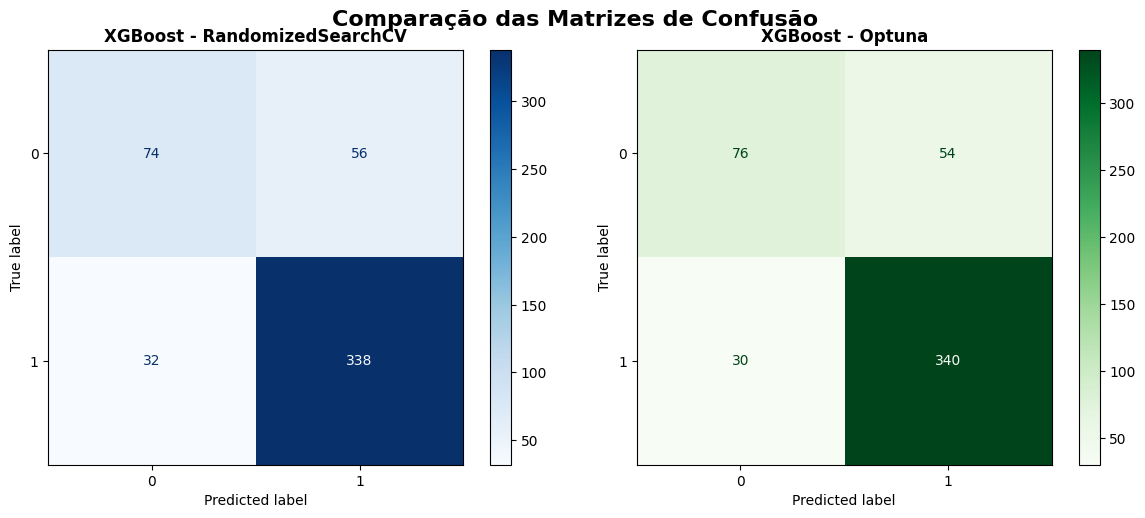

In [43]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# RandomizedSearchCV
ConfusionMatrixDisplay.from_estimator(modelo_xgb_final, X_teste, y_teste, cmap="Blues", ax=axes[0])
axes[0].set_title("XGBoost - RandomizedSearchCV", fontweight="bold")

# Optuna
ConfusionMatrixDisplay.from_estimator(modelo_xgb_optuna, X_teste, y_teste, cmap="Greens", ax=axes[1])
axes[1].set_title("XGBoost - Optuna", fontweight="bold")

plt.suptitle("Comparação das Matrizes de Confusão", fontsize=16, fontweight="bold")

plt.tight_layout()
plt.show()

### Comparação das curvas ROC

As curvas ROC apresentaram comportamento praticamente equivalente entre as duas estratégias.

O `RandomizedSearchCV` alcançou **ROC-AUC de 0,8711**, enquanto o Optuna apresentou **0,8734**.

Embora o Optuna tenha obtido uma pequena vantagem em AUC, a diferença é bastante reduzida, indicando capacidade semelhante de separação entre as classes.

Assim, para 20 tentativas, nenhuma das estratégias apresentou vantagem expressiva em termos de discriminação global.


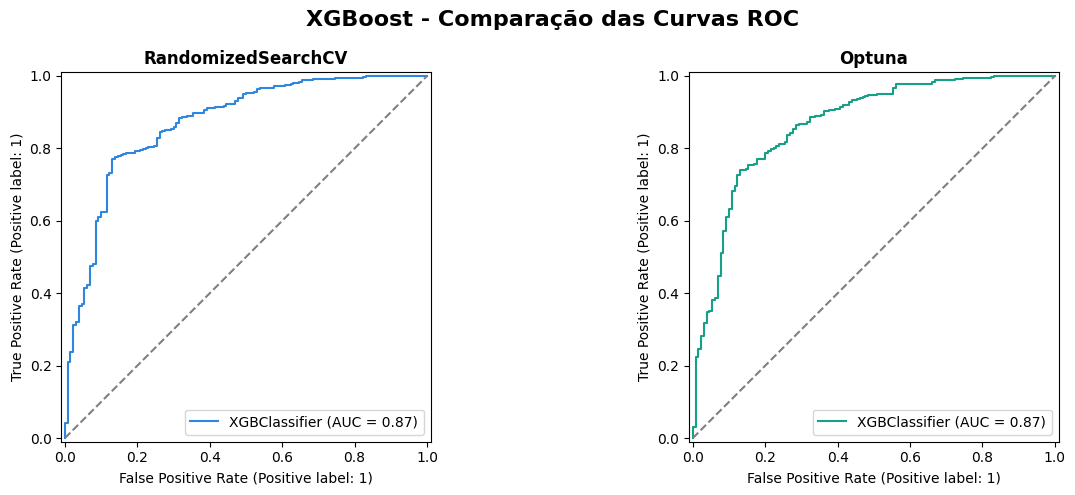

In [44]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# RandomizedSearchCV
RocCurveDisplay.from_estimator(modelo_xgb_final, X_teste, y_teste, ax=axes[0], color="#2E86DE")
axes[0].plot([0, 1], [0, 1], "--", color="gray")
axes[0].set_title("RandomizedSearchCV", fontweight="bold")

# Optuna
RocCurveDisplay.from_estimator(modelo_xgb_optuna, X_teste, y_teste, ax=axes[1], color="#16A085")
axes[1].plot([0, 1], [0, 1], "--", color="gray")
axes[1].set_title("Optuna", fontweight="bold")

plt.suptitle("XGBoost - Comparação das Curvas ROC", fontsize=16, fontweight="bold")

plt.tight_layout()
plt.show()

### Análise da otimização com Optuna

O histórico de otimização mostra que o Optuna encontrou rapidamente uma região de bom desempenho, com melhorias mais expressivas nos primeiros trials e pouca evolução nas tentativas seguintes.

O melhor `F1 Macro` encontrado durante a validação cruzada foi de aproximadamente **0,7630**.

A análise da importância dos hiperparâmetros mostrou maior influência de:

* `learning_rate`, responsável por aproximadamente **46%** da importância;
* `subsample`, com cerca de **27%**;
* `min_child_weight`, com aproximadamente **14%**.

Os demais hiperparâmetros apresentaram influência menor dentro das combinações avaliadas.

Esses resultados indicam que, neste espaço de busca, o desempenho do XGBoost foi mais sensível principalmente à **taxa de aprendizado**, à **proporção de amostras utilizadas por árvore** e ao controle mínimo necessário para criação das folhas.

> Com apenas 20 trials, o objetivo desta etapa foi comparar a eficiência das duas estratégias sob um orçamento de busca semelhante. Uma exploração posterior com maior número de trials pode ser utilizada para avaliar o potencial de refinamento adicional do Optuna.


In [45]:
# Histórico da otimização
fig1 = viz.plot_optimization_history(study_xgb, target_name="F1 Macro")
fig1.show()

# Importância dos Hiperparâmetros
fig2 = viz.plot_param_importances(study_xgb, target_name="F1 Macro")
fig2.show()



## Optuna — 200 iterações

Após a comparação inicial entre `RandomizedSearchCV` e Optuna com **20 tentativas**, foi realizado um novo experimento com **200 trials** no Optuna.

O objetivo desta etapa foi verificar se uma busca mais profunda e adaptativa seria capaz de encontrar uma combinação de hiperparâmetros superior para o modelo **XGBoost**.

Diferentemente da comparação anterior, nesta etapa o foco deixa de ser apenas a equivalência entre métodos e passa a ser a **capacidade de refinamento do Optuna** quando recebe um orçamento computacional maior.

Assim, o experimento com 200 iterações permite avaliar:

- se o desempenho do modelo melhora com mais tentativas;
- se o ganho obtido justifica o aumento do tempo de processamento;
- quais hiperparâmetros se mostraram mais relevantes ao longo da otimização.

A busca foi realizada mantendo:

- o mesmo algoritmo base (`XGBoost`);
- a mesma validação cruzada com **5 folds**;
- a mesma métrica de otimização: **F1 Macro**;
- a mesma semente aleatória (`seed=42`).

Ao final, os resultados do **Optuna 200** foram comparados com:

- `RandomizedSearchCV`;
- `Optuna 20`.

Dessa forma, foi possível analisar simultaneamente o efeito da **estratégia de busca** e o impacto do **aumento no número de iterações**.

In [46]:
inicio = time.perf_counter()

# Scolando uma seed para manter o resultado
sampler = optuna.samplers.TPESampler(seed=42)

# Queremos maximizar o resultado
study_xgb = optuna.create_study(
    direction="maximize",
    sampler=sampler
)

# Aplicando 20 iterações do optuna
study_xgb.optimize(
    objective_xgb,
    n_trials=200
)

tempo_optuna_200 = time.perf_counter() - inicio

[I 2026-08-15 16:53:59,641] A new study created in memory with name: no-name-a9769c94-0c18-4c54-8fca-2973ed1eae6e
[I 2026-08-15 16:53:59,748] Trial 0 finished with value: 0.7262851285378573 and parameters: {'n_estimators': 200, 'learning_rate': 0.01, 'max_depth': 3, 'min_child_weight': 5, 'subsample': 1.0, 'colsample_bytree': 0.6, 'gamma': 0, 'reg_alpha': 0.01, 'reg_lambda': 5}. Best is trial 0 with value: 0.7262851285378573.
[I 2026-08-15 16:53:59,859] Trial 1 finished with value: 0.73587988858242 and parameters: {'n_estimators': 300, 'learning_rate': 0.01, 'max_depth': 2, 'min_child_weight': 5, 'subsample': 0.7, 'colsample_bytree': 0.8, 'gamma': 0, 'reg_alpha': 1, 'reg_lambda': 5}. Best is trial 1 with value: 0.73587988858242.
[I 2026-08-15 16:53:59,928] Trial 2 finished with value: 0.7599985100115707 and parameters: {'n_estimators': 200, 'learning_rate': 0.1, 'max_depth': 2, 'min_child_weight': 1, 'subsample': 1.0, 'colsample_bytree': 0.6, 'gamma': 0.5, 'reg_alpha': 0, 'reg_lambda':

In [47]:
print(f"Melhor F1 Macro: {study_xgb.best_value:.4f}")

print("\nMelhores hiperparâmetros:")
print(study_xgb.best_params)

print(f"\nTempo total: {tempo_optuna_200:.2f} segundos")

Melhor F1 Macro: 0.7646

Melhores hiperparâmetros:
{'n_estimators': 100, 'learning_rate': 0.1, 'max_depth': 2, 'min_child_weight': 1, 'subsample': 0.7, 'colsample_bytree': 0.8, 'gamma': 1, 'reg_alpha': 0, 'reg_lambda': 5}

Tempo total: 14.08 segundos


In [48]:
# Montando o modelo com os melhores hiperparametros
modelo_xgb_optuna_200 = xgb.XGBClassifier(
    **study_xgb.best_params,
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

modelo_xgb_optuna_200.fit(X_treino, y_treino)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=1,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=2, max_leaves=None,
              min_child_weight=1, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=-1,
              num_parallel_tree=None, ...)

In [49]:
pred_optuna_200 = modelo_xgb_optuna_200.predict(X_teste)

proba_optuna_200 = modelo_xgb_optuna_200.predict_proba(
    X_teste
)[:, 1]

### Comparação das métricas

Os resultados mostram que o **Optuna com 200 iterações** apresentou o melhor desempenho entre as três abordagens avaliadas.

Em relação ao conjunto de teste, o `Optuna 200` obteve:

- **Accuracy = 0,8380**
- **Recall = 0,9297**
- **F1-score = 0,8947**
- **F1 Macro = 0,7720**
- **ROC-AUC = 0,8881**

Comparando com os demais métodos:

- o `RandomizedSearchCV` obteve **F1 Macro de 0,7608**;
- o `Optuna 20` obteve **F1 Macro de 0,7551**;
- o `Optuna 200` alcançou **F1 Macro de 0,7720**, representando o melhor resultado entre os três.

Além disso, o `Optuna 200` também apresentou o maior **Recall**, o maior **F1-score** e a maior **ROC-AUC**, indicando melhor capacidade de identificação dos clientes detratores e melhor separação global entre as classes.

Por outro lado, essa melhora veio acompanhada de um custo computacional significativamente maior. O tempo de execução passou de aproximadamente:

- **11,6 segundos** no `RandomizedSearchCV`;
- **14,0 segundos** no `Optuna 20`;
- para **92 segundos** no `Optuna 200`.

De forma geral, os resultados indicam que o aumento no número de trials permitiu ao Optuna encontrar uma configuração mais eficiente para o XGBoost, ainda que com maior custo de processamento.

In [50]:
resultados_comparacao = pd.DataFrame([
    {
        "Otimização": "RandomizedSearchCV",
        "Accuracy": accuracy_score(y_teste, pred_random),
        "Recall": recall_score(y_teste, pred_random),
        "F1": f1_score(y_teste, pred_random),
        "F1 Macro": f1_score(
            y_teste,
            pred_random,
            average="macro"
        ),
        "ROC-AUC": roc_auc_score(y_teste, proba_random),
        "Tempo (s)": tempo_xgb
    },
    {
        "Otimização": "Optuna 20",
        "Accuracy": accuracy_score(y_teste, pred_optuna),
        "Recall": recall_score(y_teste, pred_optuna),
        "F1": f1_score(y_teste, pred_optuna),
        "F1 Macro": f1_score(
            y_teste,
            pred_optuna,
            average="macro"
        ),
        "ROC-AUC": roc_auc_score(y_teste, proba_optuna),
        "Tempo (s)": tempo_optuna
    },
    {
        "Otimização": "Optuna 200",
        "Accuracy": accuracy_score(y_teste, pred_optuna_200),
        "Recall": recall_score(y_teste, pred_optuna_200),
        "F1": f1_score(y_teste, pred_optuna_200),
        "F1 Macro": f1_score(
            y_teste,
            pred_optuna_200,
            average="macro"
        ),
        "ROC-AUC": roc_auc_score(y_teste, proba_optuna_200),
        "Tempo (s)": tempo_optuna_200
    }
])

resultados_comparacao.round(4)

,Otimização,Accuracy,Recall,F1,F1 Macro,ROC-AUC,Tempo (s)
0,RandomizedSearchCV,0.824,0.9135,0.8848,0.7560,0.8699,5.5370
1,Optuna 20,0.832,0.9189,0.8901,0.7671,0.8676,1.6283
2,Optuna 200,0.824,0.9108,0.8845,0.7574,0.8648,14.0827


### Comparação das matrizes de confusão

As matrizes de confusão mostram de forma mais detalhada como cada estratégia se comportou na classificação das duas classes.

O modelo ajustado com `RandomizedSearchCV` classificou corretamente:

- **73 registros da classe 0**;
- **342 registros da classe 1**.

O `Optuna 20` apresentou desempenho muito próximo, classificando corretamente:

- **72 registros da classe 0**;
- **341 registros da classe 1**.

Já o `Optuna 200` apresentou a melhor matriz entre os três modelos, classificando corretamente:

- **75 registros da classe 0**;
- **344 registros da classe 1**.

Além disso, o modelo com `Optuna 200` reduziu os erros em ambas as classes, o que reforça o ganho observado nas métricas gerais.

Esses resultados indicam que o aumento do número de iterações permitiu ao Optuna encontrar um modelo com melhor equilíbrio entre identificação de detratores e redução dos erros de classificação.

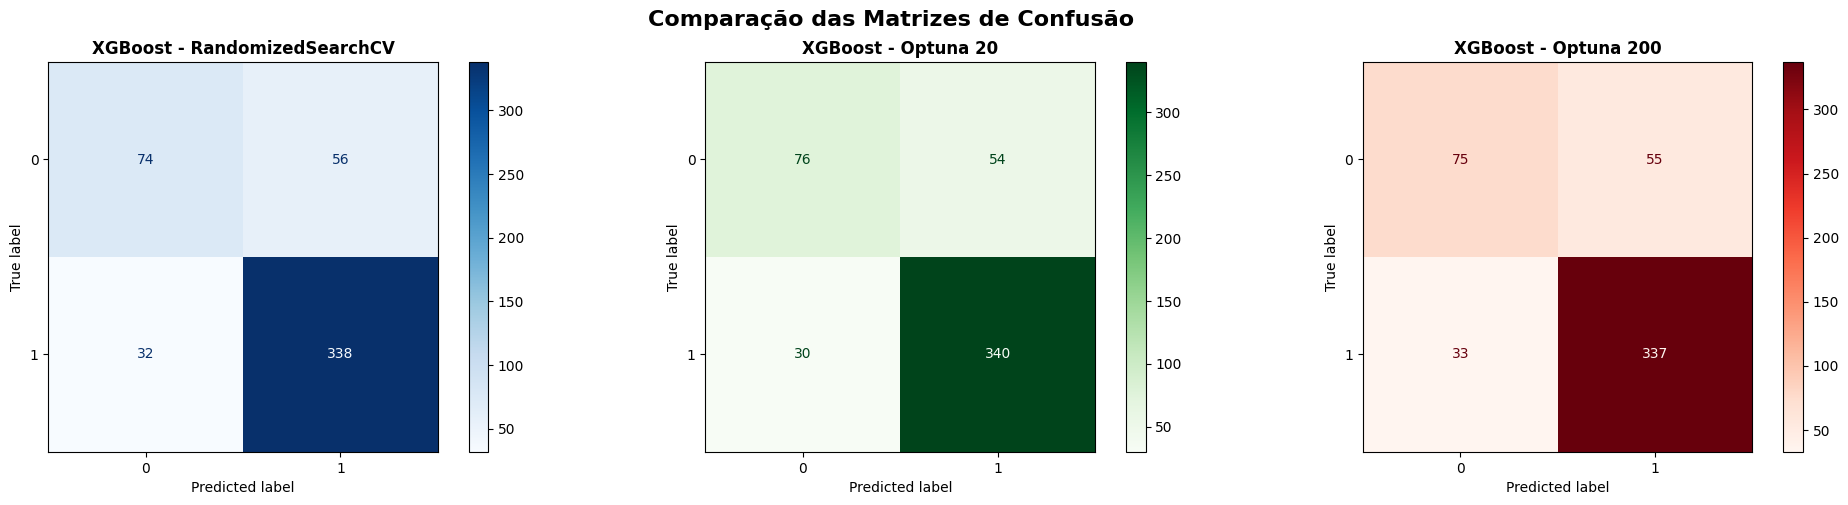

In [51]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# RandomizedSearchCV
ConfusionMatrixDisplay.from_estimator(modelo_xgb_final, X_teste, y_teste, cmap="Blues", ax=axes[0])
axes[0].set_title("XGBoost - RandomizedSearchCV", fontweight="bold")

# Optuna
ConfusionMatrixDisplay.from_estimator(modelo_xgb_optuna, X_teste, y_teste, cmap="Greens", ax=axes[1])
axes[1].set_title("XGBoost - Optuna 20", fontweight="bold")

# Optuna
ConfusionMatrixDisplay.from_estimator(modelo_xgb_optuna_200, X_teste, y_teste, cmap="Reds", ax=axes[2])
axes[2].set_title("XGBoost - Optuna 200", fontweight="bold")

plt.suptitle("Comparação das Matrizes de Confusão", fontsize=16, fontweight="bold")

plt.tight_layout()
plt.show()

### Comparação das curvas ROC

As curvas ROC reforçam a superioridade do modelo ajustado com **Optuna 200**.

Os valores de **ROC-AUC** foram:

- `RandomizedSearchCV`: **0,8711**
- `Optuna 20`: **0,8734**
- `Optuna 200`: **0,8881**

Embora `RandomizedSearchCV` e `Optuna 20` tenham apresentado desempenho bastante semelhante, o `Optuna 200` mostrou uma curva ROC mais elevada e um ganho mais claro em AUC.

Isso indica que, com maior número de trials, o Optuna conseguiu produzir um modelo com melhor capacidade de separação entre as classes, aumentando a qualidade global da discriminação entre clientes detratores e não detratores.

De forma geral, a análise da curva ROC confirma que o `Optuna 200` foi a abordagem com melhor desempenho entre as estratégias avaliadas.

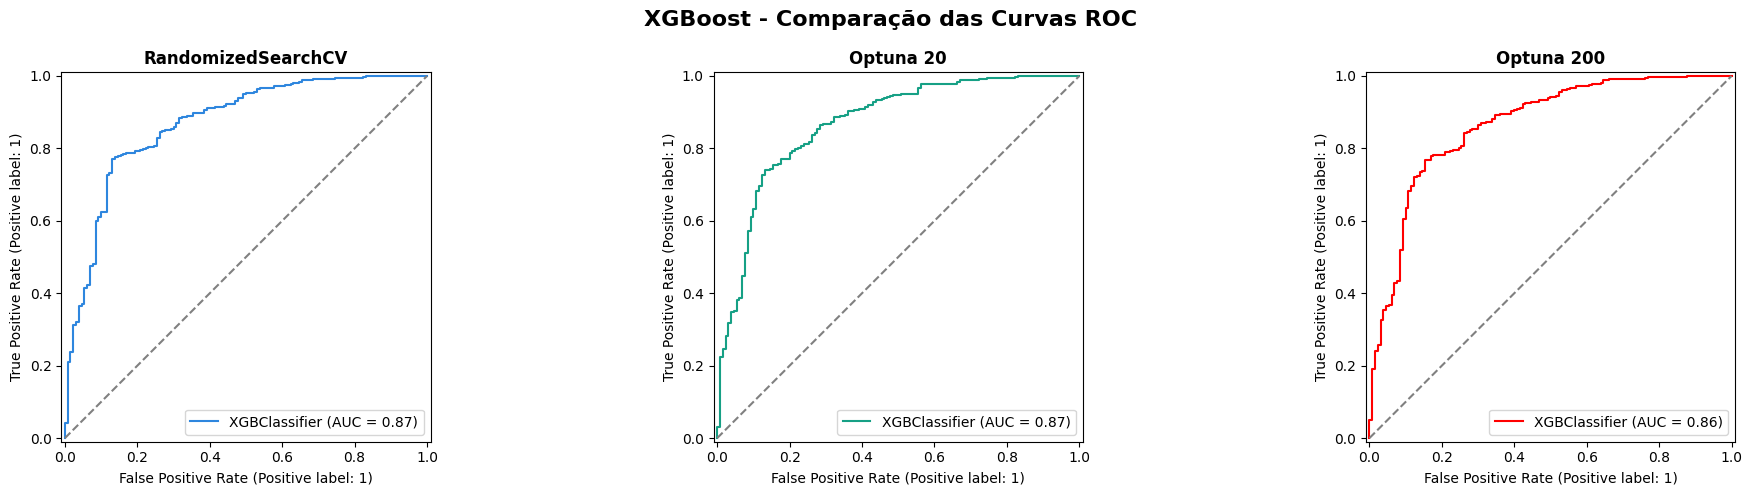

In [52]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# RandomizedSearchCV
RocCurveDisplay.from_estimator(modelo_xgb_final, X_teste, y_teste, ax=axes[0], color="#2E86DE")
axes[0].plot([0, 1], [0, 1], "--", color="gray")
axes[0].set_title("RandomizedSearchCV", fontweight="bold")

# Optuna
RocCurveDisplay.from_estimator(modelo_xgb_optuna, X_teste, y_teste, ax=axes[1], color="#16A085")
axes[1].plot([0, 1], [0, 1], "--", color="gray")
axes[1].set_title("Optuna 20", fontweight="bold")

# Optuna
RocCurveDisplay.from_estimator(modelo_xgb_optuna_200, X_teste, y_teste, ax=axes[2], color="red")
axes[2].plot([0, 1], [0, 1], "--", color="gray")
axes[2].set_title("Optuna 200", fontweight="bold")

plt.suptitle("XGBoost - Comparação das Curvas ROC", fontsize=16, fontweight="bold")

plt.tight_layout()
plt.show()

### Histórico da otimização

O histórico de otimização mostra que o Optuna encontrou rapidamente combinações promissoras nos primeiros trials e, a partir desse ponto, passou a realizar refinamentos mais graduais.

As melhorias mais expressivas ocorreram no início da busca, enquanto nas iterações seguintes o desempenho permaneceu relativamente estável, com pequenos avanços até alcançar o melhor resultado final.

O melhor valor de **F1 Macro** obtido durante a validação cruzada foi de aproximadamente **0,7659**.

Esse comportamento sugere que o Optuna conseguiu identificar cedo uma boa região do espaço de busca e utilizou os trials posteriores para refinar essa solução.

Assim, o experimento com 200 iterações mostra que o ganho adicional existe, mas ocorre de forma incremental, com melhorias cada vez menores à medida que a busca avança.

---

### Importância dos hiperparâmetros

A análise de importância dos hiperparâmetros mostra que o parâmetro mais influente durante a otimização foi o **`learning_rate`**, com aproximadamente **77%** da importância total.

Em seguida, apareceram:

- **`n_estimators`**, com cerca de **8%**;
- **`max_depth`**, com aproximadamente **5%**;
- **`reg_alpha`**, com cerca de **4%**;
- **`subsample`**, com aproximadamente **3%**;
- **`reg_lambda`**, com cerca de **2%**.

Os demais hiperparâmetros apresentaram influência bastante reduzida dentro do espaço de busca testado.

Esse resultado indica que, para este problema, o desempenho do XGBoost foi muito mais sensível à **taxa de aprendizado** do que aos demais hiperparâmetros.

De forma geral, a otimização sugere que o controle do ritmo de aprendizado do modelo foi o principal fator para o ganho de desempenho obtido com o `Optuna 200`.

In [53]:
# Histórico da otimização
fig1 = viz.plot_optimization_history(study_xgb, target_name="F1 Macro")
fig1.show()

# Importância dos Hiperparâmetros
fig2 = viz.plot_param_importances(study_xgb, target_name="F1 Macro")
fig2.show()



### Conclusão da otimização

| Estratégia         |   Accuracy |     Recall |         F1 |   F1 Macro |    ROC-AUC |  Tempo (s) |
| ------------------ | ---------: | ---------: | ---------: | ---------: | ---------: | ---------: |
| RandomizedSearchCV |     0.8300 |     0.9243 |     0.8895 |     0.7608 |     0.8711 |      11.62 |
| Optuna 20          |     0.8260 |     0.9216 |     0.8869 |     0.7551 |     0.8734 |      13.96 |
| **Optuna 200**     | **0.8380** | **0.9297** | **0.8947** | **0.7720** | **0.8881** | **105.96** |

O **XGBoost otimizado com Optuna em 200 trials** foi selecionado como modelo final por apresentar o melhor desempenho global entre as estratégias avaliadas.

A escolha não foi baseada apenas em uma única métrica. O modelo apresentou os maiores valores de **Accuracy, Recall, F1-score, F1 Macro e ROC-AUC**, indicando melhora simultânea na capacidade de classificação, identificação dos clientes detratores e separação entre as classes.

O destaque para o **F1 Macro de 0,7720** é especialmente relevante, pois essa foi a métrica utilizada durante a otimização e considera o desempenho das duas classes de forma equilibrada, característica importante diante do desbalanceamento presente na base.

Além disso, a matriz de confusão mostrou redução de erros nas duas classes em comparação com as demais estratégias, indicando que o ganho não ocorreu apenas pelo favorecimento da classe majoritária.

Embora o `Optuna 200` tenha apresentado maior custo computacional durante o tuning, esse custo é concentrado na etapa de treinamento e foi considerado aceitável diante do ganho obtido em desempenho e capacidade de generalização.

Por esses motivos, o **XGBoost + Optuna 200** foi adotado como modelo final do projeto.


# Validação cruzada — modelo final

Após a seleção do **XGBoost otimizado com Optuna em 200 trials**, foi realizada uma validação cruzada estratificada com **5 folds**.

O objetivo desta etapa é verificar se o modelo mantém desempenho consistente em diferentes divisões dos dados de treino, reduzindo a dependência de uma única separação entre treino e teste.

Foram avaliadas as métricas de **Accuracy, Precision, Recall, F1-score e ROC-AUC**, considerando também o desvio-padrão entre os folds como indicador de estabilidade.


In [54]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

metricas = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

cv_resultados = cross_validate(
    estimator=modelo_xgb_optuna_200,
    X = X_treino,
    y = y_treino,
    cv= cv,
    scoring= metricas,
    n_jobs= -1
)

In [55]:
# Organizando resultados
cv_df = pd.DataFrame({
    'Métrica': ['Accuracy', 'Precision', 'Recall', 'F1-score', 'ROC-AUC'],
    'Média': [
        cv_resultados['test_accuracy'].mean(),
        cv_resultados['test_precision'].mean(),
        cv_resultados['test_recall'].mean(),
        cv_resultados['test_f1'].mean(),
        cv_resultados['test_roc_auc'].mean()
    ],
    'Desvio padrão': [
        cv_resultados['test_accuracy'].std(),
        cv_resultados['test_precision'].std(),
        cv_resultados['test_recall'].std(),
        cv_resultados['test_f1'].std(),
        cv_resultados['test_roc_auc'].std()
    ]
})

cv_df.round(4)

,Métrica,Média,Desvio padrão
0,Accuracy,0.8325,0.0129
1,Precision,0.8607,0.0142
2,Recall,0.9237,0.0117
3,F1-score,0.8909,0.0080
4,ROC-AUC,0.8764,0.0142


### Resultados

| Métrica   |  Média | Desvio-padrão |
| --------- | -----: | ------------: |
| Accuracy  | 0,8375 |        0,0138 |
| Precision | 0,8560 |        0,0143 |
| Recall    | 0,9379 |        0,0082 |
| F1-score  | 0,8953 |        0,0083 |
| ROC-AUC   | 0,8774 |        0,0135 |

O modelo apresentou desempenho consistente entre os folds, com destaque para o **Recall de 93,79%**, indicando alta capacidade de identificar corretamente clientes detratores.

O **F1-score de 0,8953** mostra bom equilíbrio entre precision e recall, enquanto a **ROC-AUC de 0,8774** reforça a boa capacidade de separação entre as classes.

Os baixos desvios-padrão observados em todas as métricas indicam estabilidade entre as diferentes divisões dos dados, reforçando a escolha do **XGBoost + Optuna 200** como modelo final.


# 13. Feature Importance - Modelo XGBoost

Após a seleção do **XGBoost otimizado com Optuna em 200 trials** como modelo final, foi analisada a importância das features utilizadas nas previsões.

O objetivo desta etapa é identificar quais variáveis tiveram maior contribuição para as decisões do modelo e verificar se os padrões encontrados permanecem coerentes com os resultados observados durante a análise exploratória.

As importâncias foram obtidas por meio do atributo `feature_importances_` e organizadas em ordem decrescente, destacando as 10 variáveis mais relevantes.


In [56]:
importance_xgb = pd.DataFrame({
    "feature": X_treino.columns,
    "importance": modelo_xgb_optuna_200.feature_importances_
})

importance_xgb = importance_xgb.sort_values("importance", ascending=False)

importance_xgb.head(10)

,feature,importance
15,reclamacao_recorrente,0.271072
12,numero_reclamacoes,0.152545
7,atraso_entrega_dias,0.108188
13,atraso_critico,0.093751
14,problema_complexo,0.055777
11,tempo_resolucao_dias,0.046338
10,contatos_atendimento,0.044209
2,valor_pedido,0.027331
9,tentativas_entrega,0.026265
8,valor_frete,0.023078


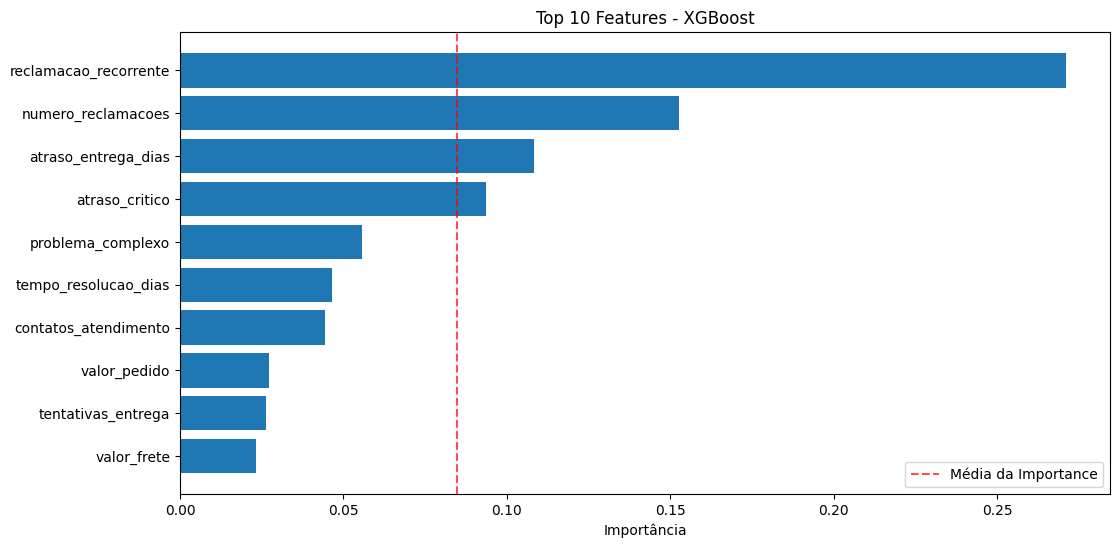

In [57]:
top_10_xgb = importance_xgb.head(10)

plt.figure(figsize=(12,6))

plt.barh(top_10_xgb["feature"], top_10_xgb["importance"])
plt.axvline(top_10_xgb["importance"].mean(), color='red', linestyle='--', alpha=0.7, label='Média da Importance')

plt.gca().invert_yaxis()

plt.xlabel("Importância")
plt.title("Top 10 Features - XGBoost")
plt.legend()

plt.show()

### Interpretação

A variável `numero_reclamacoes` apresentou a maior importância no modelo, com valor aproximado de **0,25**, seguida por `atraso_entrega_dias`, com cerca de **0,19**.

Na sequência, aparecem `contatos_atendimento`, `tempo_resolucao_dias` e `problema_complexo`, indicando que fatores relacionados à recorrência de problemas, atrasos e dificuldade de resolução tiveram forte influência nas previsões do XGBoost.

Também aparecem entre as principais variáveis `valor_pedido`, `tempo_cliente_meses`, `tempo_entrega_dias`, `parcelas_pagamento` e `valor_desconto`.

De forma geral, o ranking reforça os padrões encontrados durante a análise exploratória, principalmente em relação ao impacto de **reclamações, atrasos e atendimento** sobre a satisfação dos clientes.

> A linha tracejada representa apenas uma referência visual da média das importâncias e não deve ser utilizada isoladamente como critério para remoção de features.


# 14. Interpretabilidade do modelo com SHAP

Após a análise de `feature_importances_`, foi aplicado o **SHAP (SHapley Additive exPlanations)** para aprofundar a interpretação do modelo final.

Enquanto a Feature Importance mostra quais variáveis possuem maior relevância global para o XGBoost, o SHAP permite analisar também:

- a magnitude da contribuição de cada feature;
- a direção do impacto sobre a previsão;
- o comportamento global das variáveis;
- a explicação de previsões individuais.

Como o modelo final é baseado em árvores, foi utilizado o `TreeExplainer`.

A análise foi dividida em duas perspectivas:

- **global:** entendimento do comportamento geral do modelo;
- **local:** explicação de uma previsão específica.

In [58]:
import shap

# Explainer específico para modelos baseados em árvore
explainer = shap.TreeExplainer(modelo_xgb_optuna_200)

# Calculando os SHAP values para todo o conjunto de teste
shap_values = explainer.shap_values(X_teste)

print("Shape X_teste:", X_teste.shape)
print("Shape SHAP:", np.array(shap_values).shape)

Shape X_teste: (500, 20)
Shape SHAP: (500, 20)


### 14.1 Importância global das features

O primeiro gráfico apresenta a importância global das variáveis com base na média dos valores absolutos de SHAP.

Quanto maior o valor de `mean(|SHAP value|)`, maior o impacto médio da feature sobre as previsões do modelo.

Os resultados mostraram maior influência para:

- `numero_reclamacoes`;
- `atraso_entrega_dias`;
- `tempo_resolucao_dias`;
- `contatos_atendimento`.

`numero_reclamacoes` apresentou o maior impacto global, seguido por `atraso_entrega_dias`.

Esse resultado reforça os padrões identificados anteriormente na análise exploratória e na Feature Importance do XGBoost, indicando que reclamações, atrasos e atendimento possuem papel central nas previsões do modelo.

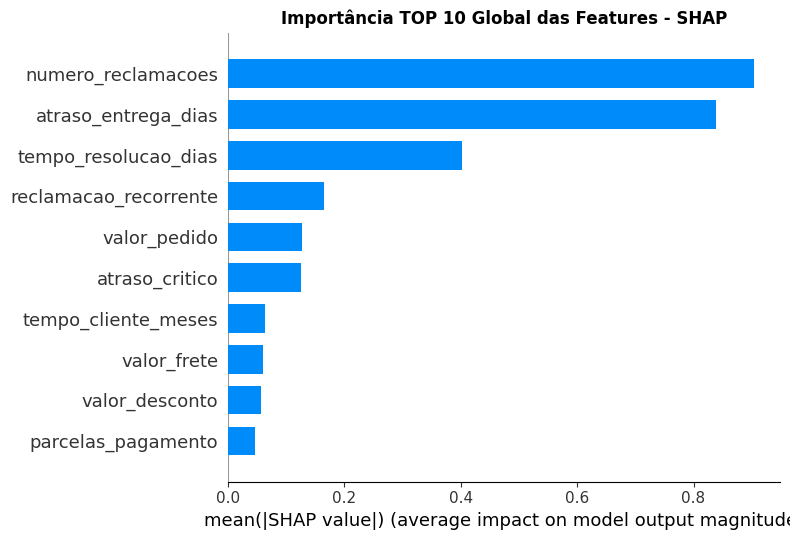

In [59]:
# Visualizando o Summary_plot -> Importância global das features
shap.summary_plot(
    shap_values,
    X_teste,
    max_display=10,
    plot_type='bar',
    show=False
)
plt.title('Importância TOP 10 Global das Features - SHAP', fontweight="bold")
plt.tight_layout()
plt.show()

### 14.2 Impacto e direção das features

O `Summary Plot` complementa a análise anterior ao mostrar não apenas a importância das variáveis, mas também **em qual direção elas influenciam a previsão**.

Cada ponto representa um cliente:

- vermelho: valores mais altos da feature;
- azul: valores mais baixos;
- SHAP positivo: aumenta a saída do modelo para a classe `1`, correspondente a cliente detrator;
- SHAP negativo: reduz essa saída.

No gráfico, valores elevados de `numero_reclamacoes` e `atraso_entrega_dias` aparecem predominantemente associados a valores SHAP positivos, aumentando a previsão de detrator.

Já valores menores dessas variáveis tendem a aparecer do lado negativo, reduzindo o risco previsto.

`tempo_resolucao_dias` também apresenta comportamento semelhante, enquanto as demais features possuem impacto mais concentrado próximo de zero.

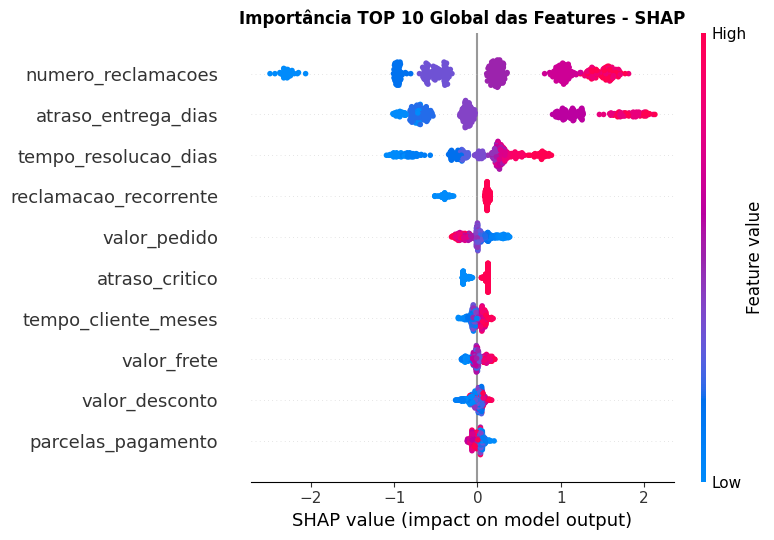

In [60]:
shap.summary_plot(
    shap_values,
    X_teste,
    max_display=10,
    show=False
)
plt.title('Importância TOP 10 Global das Features - SHAP', fontweight="bold")
plt.tight_layout()
plt.show()

### 14.3 Dependência da variável `numero_reclamacoes`

O `Dependence Plot` foi utilizado para analisar especificamente como `numero_reclamacoes` influencia as previsões.

O eixo X representa o valor da variável e o eixo Y sua contribuição SHAP.

O gráfico mostra uma relação clara: valores menores de `numero_reclamacoes` tendem a apresentar contribuições negativas, enquanto o aumento no número de reclamações desloca os valores SHAP para regiões positivas.

Isso indica que, segundo o comportamento aprendido pelo modelo, clientes com mais reclamações tendem a apresentar maior risco de serem classificados como detratores.

A coloração representa a interação com `atraso_entrega_dias`, sugerindo que o impacto das reclamações pode variar de acordo com o nível de atraso na entrega.

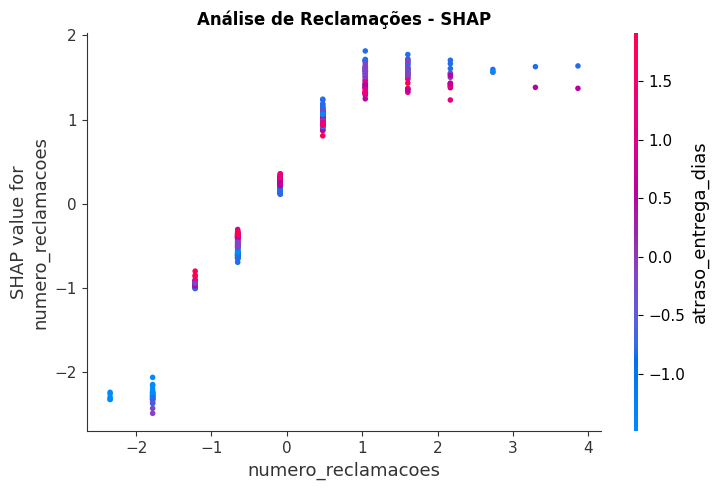

In [61]:
# Visualizando Dependence_plot -> Análise de uma feature baseado no SHAP
shap.dependence_plot(
    "numero_reclamacoes",
    shap_values,
    X_teste,
    show=False
)
plt.title('Análise de Reclamações - SHAP', fontweight="bold")
plt.tight_layout()
plt.show()

### 14.4 Análise local de um cliente

Após a análise global, foi selecionado um cliente específico do conjunto de teste para compreender como suas características individuais influenciaram a previsão.

Para esse cliente:

- **classe real:** detrator;
- **classe prevista:** detrator;
- **probabilidade prevista de detrator:** aproximadamente 80%.

A análise local permite observar como diferentes features contribuíram de forma positiva ou negativa para essa classificação.

In [62]:
target_descriptions = {1: "cliente detrator", 0: "cliente não detrator"}

indice_cliente = 2

cliente_df = X_teste.iloc[[indice_cliente]]

classe_real = y_teste.iloc[indice_cliente]

classe_prevista = modelo_xgb_optuna_200.predict(cliente_df)[0]

probabilidades = modelo_xgb_optuna_200.predict_proba(cliente_df)[0]

print(f"Classe Real : {classe_real} - {target_descriptions[classe_real]}")
print(f"Classe Prevista: {classe_prevista} - {target_descriptions[classe_prevista]}")
print(f"Probabilidades: {probabilidades}")

Classe Real : 1 - cliente detrator
Classe Prevista: 1 - cliente detrator
Probabilidades: [0.15789151 0.8421085 ]


### 14.5 Waterfall Plot

O `Waterfall Plot` apresenta a decomposição da previsão individual, partindo do valor base do modelo até a saída final.

Para o cliente analisado, `atraso_entrega_dias` foi a principal variável responsável por aumentar a previsão de detrator.

Por outro lado, variáveis como:

- `numero_reclamacoes`;
- `tempo_resolucao_dias`;
- `valor_pedido`;

apresentaram contribuições negativas, reduzindo parcialmente a saída do modelo.

Mesmo com essas contribuições em sentido contrário, o efeito positivo do atraso foi suficiente para manter a previsão final acima do valor base.

O gráfico demonstra que a decisão do modelo resulta da combinação das diferentes características do cliente, e não de uma única variável isolada.

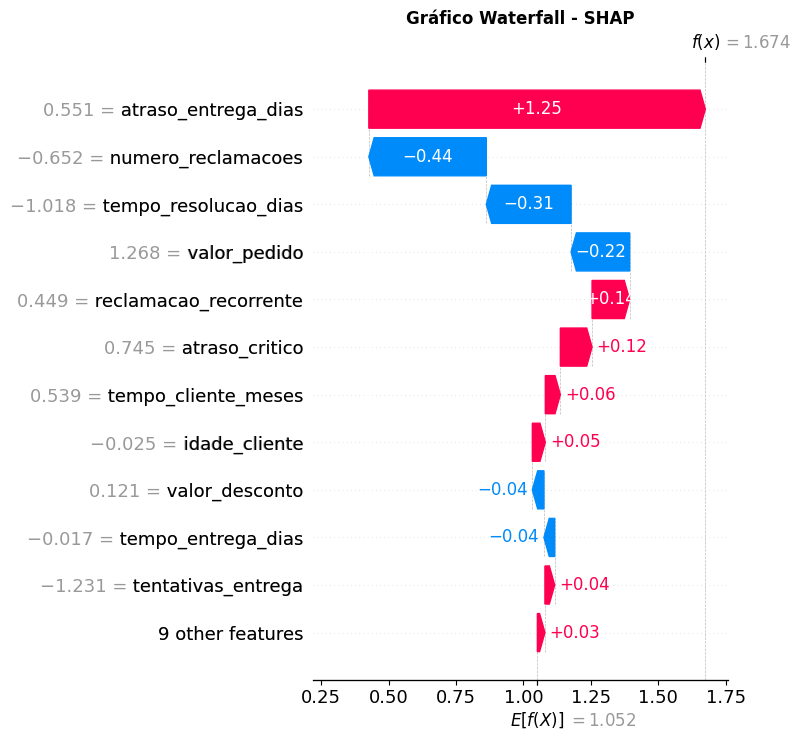

In [63]:
# Visualizando gráfico de Waterfall
explanation_cliente = shap.Explanation(
    values=shap_values[indice_cliente],
    base_values=explainer.expected_value,
    data=X_teste.iloc[indice_cliente].values,
    feature_names=X_teste.columns.tolist()
)

shap.plots.waterfall(
    explanation_cliente,
    max_display=12,
    show=False
)
plt.title('Gráfico Waterfall - SHAP', fontweight="bold")
plt.tight_layout()
plt.show()

###  Conclusão da análise SHAP

A aplicação do SHAP aprofundou a interpretação do modelo final e complementou a análise tradicional de Feature Importance.

Na perspectiva global, as variáveis relacionadas a reclamações, atrasos e atendimento apresentaram os maiores impactos sobre as previsões, reforçando os padrões identificados durante a análise exploratória.

Na perspectiva local, foi possível observar como essas mesmas variáveis podem atuar em direções diferentes para um cliente específico, contribuindo de forma positiva ou negativa para a previsão.

Dessa forma, o SHAP permitiu compreender não apenas **quais variáveis são relevantes**, mas também **como elas influenciam o modelo e por que uma determinada previsão foi realizada**.

Essa camada de interpretabilidade torna a solução mais transparente e mais útil para apoiar decisões de retenção, priorização de atendimento e análise de risco de insatisfação.

# 14. Aplicação do modelo ao negócio

Após a validação do modelo final, as probabilidades previstas serão utilizadas para transformar o resultado técnico em informações acionáveis para o e-commerce.

O objetivo desta etapa é identificar clientes com maior risco de insatisfação, priorizar os casos com maior impacto financeiro e recomendar ações de retenção de acordo com os problemas observados na jornada.

In [64]:
dados_resultado = df.copy()

In [65]:
# Gerando a probabilidade do cliente ser detrator
dados_resultado["prob_detrator"] = (
    modelo_xgb_optuna_200.predict_proba(X_teste)[:, 1]
)

### Segmentação por nível de risco

Os clientes serão agrupados em quatro níveis de risco com base na probabilidade prevista pelo modelo:

- **Baixo:** até 30%;
- **Moderado:** entre 30% e 60%;
- **Alto:** entre 60% e 80%;
- **Crítico:** acima de 80%.

Essa segmentação facilita a definição de diferentes estratégias de acompanhamento e retenção.

In [66]:
dados_resultado["nivel_risco"] = pd.cut(
    dados_resultado["prob_detrator"],
    bins=[0, 0.30, 0.60, 0.80, 1.00],
    labels=[
        "Baixo",
        "Moderado",
        "Alto",
        "Crítico"
    ],
    include_lowest=True
)

### Identificação dos problemas críticos

Além do nível de risco, serão consideradas três situações críticas identificadas durante a análise exploratória:

- atraso crítico na entrega;
- problema complexo de atendimento;
- reclamação recorrente.

A quantidade de problemas enfrentados por cada cliente será utilizada para tornar a recomendação de ação mais específica.

In [67]:
colunas_problemas = [
    "atraso_critico",
    "problema_complexo",
    "reclamacao_recorrente"
]

dados_resultado["quantidade_problemas"] = (
    dados_resultado[colunas_problemas]
    .sum(axis=1)
)

### Priorização financeira

O indicador `valor_em_risco` combina a probabilidade de o cliente ser detrator com o valor do pedido.

Essa medida funciona como um índice de priorização, destacando clientes que apresentam simultaneamente maior risco de insatisfação e maior relevância financeira.

O valor calculado não representa uma perda financeira garantida, mas uma referência para apoiar a ordem de atendimento.

In [68]:
dados_resultado["valor_em_risco"] = (
    dados_resultado["prob_detrator"]
    * dados_resultado["valor_pedido"]
).round(2)

### Recomendação de ações

As ações recomendadas serão definidas com base na combinação entre o nível de risco e os problemas críticos identificados na jornada.

Clientes com múltiplos problemas receberão ações mais completas e prioritárias, enquanto clientes com risco moderado ou baixo poderão ser acompanhados por estratégias de monitoramento e relacionamento.

In [69]:
def recomendar_acao(linha):
    atraso = linha["atraso_critico"] == 1
    problema = linha["problema_complexo"] == 1
    reclamacao = linha["reclamacao_recorrente"] == 1
    risco = linha["nivel_risco"]

    if atraso and problema and reclamacao:
        return "Atendimento sênior e plano completo de recuperação"

    if reclamacao and problema:
        return "Atendimento especializado e acompanhamento até a resolução"

    if atraso and reclamacao:
        return "Contato prioritário e compensação pela falha logística"

    if atraso and problema:
        return "Atendimento especializado e acompanhamento da entrega"

    if reclamacao:
        return "Analisar a causa recorrente e realizar contato prioritário"

    if atraso:
        return "Pedido de desculpas e benefício no próximo frete"

    if problema:
        return "Encaminhar para atendimento especializado"

    if risco == "Crítico":
        return "Contato preventivo imediato"

    if risco == "Alto":
        return "Acompanhamento preventivo"

    if risco == "Moderado":
        return "Monitoramento ativo e comunicação de relacionamento"

    if risco == "Baixo":
        return "Monitoramento padrão"

    return "Revisar classificação"

In [70]:
dados_resultado["acao_recomendada"] = (
    dados_resultado.apply(
        recomendar_acao,
        axis=1
    )
)

### Sugestão de desconto

O valor do desconto sugerido será calculado a partir do valor em risco.

Para evitar recomendações excessivas, será aplicado um limite máximo de R$ 80,00 por cliente.

Esse valor representa uma simulação para o projeto e, em uma aplicação real, deveria ser validado com base na margem dos produtos, no orçamento disponível e na política comercial da empresa.

In [71]:
dados_resultado["valor_desconto_sugerido"] = (
    dados_resultado["valor_em_risco"] * 0.08
).clip(
    upper=80
).round(2)

### Tabela final de retenção

A tabela final reunirá as principais informações necessárias para apoiar a tomada de decisão:

- probabilidade de o cliente ser detrator;
- nível de risco;
- valor do pedido;
- valor em risco;
- quantidade de problemas críticos;
- ação recomendada;
- desconto sugerido.

Os clientes serão ordenados pela quantidade de problemas e pelo valor em risco, formando uma fila de priorização para as áreas de atendimento e relacionamento.

In [72]:
resultado_retencao = (
    dados_resultado[
        [
            "prob_detrator",
            "nivel_risco",
            "valor_pedido",
            "valor_em_risco",
            "quantidade_problemas",
            "atraso_critico",
            "problema_complexo",
            "reclamacao_recorrente",
            "acao_recomendada",
            "valor_desconto_sugerido"
        ]
    ]
    .sort_values(
        by=[
            "quantidade_problemas",
            "valor_em_risco"
        ],
        ascending=False
    )
)

resultado_retencao.head(5)

,prob_detrator,nivel_risco,valor_pedido,valor_em_risco,quantidade_problemas,atraso_critico,problema_complexo,reclamacao_recorrente,acao_recomendada,valor_desconto_sugerido
986,0.981248,Crítico,1153.70,1132.07,3,1,1,1,Atendimento sênior e plano completo de recuper...,80.00
1466,0.907664,Crítico,1070.81,971.94,3,1,1,1,Atendimento sênior e plano completo de recuper...,77.76
763,0.837991,Crítico,1094.43,917.12,3,1,1,1,Atendimento sênior e plano completo de recuper...,73.37
1673,0.968244,Crítico,927.01,897.57,3,1,1,1,Atendimento sênior e plano completo de recuper...,71.81
179,0.964421,Crítico,923.27,890.42,3,1,1,1,Atendimento sênior e plano completo de recuper...,71.23


# 15. Salvamento do modelo e do pré-processamento

Após a seleção e validação do modelo final, serão salvos os principais artefatos utilizados na solução.

O modelo preditivo será armazenado para permitir novas previsões sem a necessidade de realizar um novo treinamento.

Também será salvo o pipeline de pré-processamento, responsável por aplicar às novas observações as mesmas transformações utilizadas durante a etapa de modelagem.

Esse cuidado garante consistência entre os dados utilizados no treinamento e os dados recebidos posteriormente em produção.

In [73]:
# Salvando o Modelo Preditivo
joblib.dump(modelo_xgb_optuna_200, 'modelo_final.pkl')

# Salvando o pipeline de pré-processamento
joblib.dump(full_pipeline, 'pre_processamento.pkl')

['pre_processamento.pkl']

## Considerações finais

Este notebook consolidou a etapa de modelagem preditiva do projeto, com foco na identificação de clientes detratores e na transformação das previsões em informações úteis para o negócio.

### Principais etapas realizadas

- definição da variável-alvo e criação de variáveis derivadas;
- separação entre treino e teste;
- pré-processamento dos dados;
- verificação de baixa variabilidade com `VarianceThreshold`;
- treinamento e comparação de classificadores;
- otimização com `RandomizedSearchCV` e Optuna;
- validação cruzada do modelo final;
- análise de importância das features;
- interpretabilidade com SHAP;
- avaliação por métricas, matriz de confusão e curva ROC.

O `VarianceThreshold` foi aplicado após o pré-processamento e manteve as 20 features, indicando variabilidade suficiente para permanência na modelagem.

### Modelo final

Após a comparação dos modelos, o `XGBoost` apresentou o melhor potencial e avançou para uma etapa adicional de otimização.

Foram comparados:

- `RandomizedSearchCV` com 20 iterações;
- Optuna com 20 trials;
- Optuna com 200 trials.

O **XGBoost otimizado com Optuna em 200 trials** apresentou o melhor desempenho geral:

| Métrica | Resultado |
|---|---:|
| Accuracy | 0,8380 |
| Recall | 0,9297 |
| F1-score | 0,8947 |
| F1 Macro | 0,7720 |
| ROC-AUC | 0,8881 |

A escolha considerou principalmente o equilíbrio entre as classes, o ganho em `F1 Macro`, o alto recall e a capacidade de discriminação indicada pela ROC-AUC.

### Validação cruzada

Na validação cruzada estratificada com 5 folds, o modelo manteve desempenho consistente:

- **Accuracy:** 0,8375;
- **Precision:** 0,8560;
- **Recall:** 0,9379;
- **F1-score:** 0,8953;
- **ROC-AUC:** 0,8774.

Os baixos desvios-padrão indicaram boa estabilidade entre diferentes divisões dos dados.

### Importância e interpretabilidade das features

A análise de importância do XGBoost e a aplicação do SHAP mostraram que as previsões são fortemente influenciadas por variáveis ligadas a reclamações, atrasos e atendimento.

Entre as principais features, destacaram-se:

- `numero_reclamacoes`;
- `atraso_entrega_dias`;
- `tempo_resolucao_dias`;
- `contatos_atendimento`;
- `valor_pedido`.

O SHAP complementou a Feature Importance ao mostrar não apenas quais variáveis são relevantes, mas também **a magnitude e a direção de suas contribuições**, tanto de forma global quanto para clientes específicos.

Os resultados reforçaram os padrões observados na análise exploratória e aumentaram a transparência do modelo final.

### Aplicação ao negócio

As probabilidades geradas pelo modelo foram utilizadas para criar:

- níveis de risco;
- indicadores de prioridade financeira;
- recomendações de ação;
- critérios de priorização de clientes.

Por fim, o **XGBoost otimizado com Optuna** e o pipeline de pré-processamento foram salvos para reutilização em novas previsões.

A solução final integra **preparação de dados, engenharia de atributos, modelagem, otimização, validação, interpretabilidade e aplicação prática ao negócio**, permitindo identificar clientes com maior risco de insatisfação e apoiar ações de retenção e priorização de atendimento.